# EDA — Tipo Cambio

---
## 0. Configuración del Dataset

In [32]:
# ============================================================
# CONFIGURACIÓN: TIPO_CAMBIO
# ============================================================

DATASET_CONFIG = {
    'nombre': 'tipo_cambio',
    'archivo': 'tipo_de_cambio_euro_historico.csv',
    'frecuencia_original': 'diaria',
    'col_fecha': 'fecha',
    'variable_principal': 'HEUR_USD',
    'variables_desgloses': [
        'HEUR_GBP',
        'HEUR_CHF',
        'HEUR_JPY',
        'HEUR_CAD',
    ],
    'columnas_numericas': [
        'HEUR_USD',
        'HEUR_CAD',
        'HEUR_GBP',
        'HEUR_CHF',
        'HEUR_SEK',
        'HEUR_DKK',
        'HEUR_NOK',
        'HEUR_JPY',
    ],
    'unidades': 'unidades de divisa por 1 HEUR (cotización indirecta)',
    'notas': 'Banco de España / BCE. Tipos de cambio diarios. USD desde 1962, resto desde 1967.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: tipo_cambio
Variable principal:  HEUR_USD
Frecuencia:          diaria
Periodo estacional:  365


---
## Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

---
## 1. Carga y Diagnóstico Básico

In [34]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: tipo_cambio
Notas:   Banco de España / BCE. Tipos de cambio diarios. USD desde 1962, resto desde 1967.
Shape:          (15800, 12)
Rango temporal: 1974-07-01 a 2025-10-01
Observaciones:  15800
Columnas:       ['año', 'trimestre', 'mes', 'periodo', 'HEUR_USD', 'HEUR_CAD', 'HEUR_GBP', 'HEUR_CHF', 'HEUR_SEK', 'HEUR_DKK', 'HEUR_NOK', 'HEUR_JPY']


In [35]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,mes,periodo,HEUR_USD,HEUR_CAD,HEUR_GBP,HEUR_CHF,HEUR_SEK,HEUR_DKK,HEUR_NOK,HEUR_JPY
fecha,,,,,,,,,,,,
1974-07-01,1974,3,7,1974Q3,2.905,2.820,1.218,8.732,12.761,17.403,15.832,827.235
1974-07-02,1974,3,7,1974Q3,2.904,2.824,1.216,8.707,12.703,17.372,15.787,830.725
1974-07-03,1974,3,7,1974Q3,2.909,2.833,1.215,8.641,12.744,17.282,15.729,830.207



Últimas 3 filas:


,año,trimestre,mes,periodo,HEUR_USD,HEUR_CAD,HEUR_GBP,HEUR_CHF,HEUR_SEK,HEUR_DKK,HEUR_NOK,HEUR_JPY
fecha,,,,,,,,,,,,
2025-09-29,2025,3,9,2025Q3,1.172,1.633,0.872,0.936,11.030,7.465,11.678,174.380
2025-09-30,2025,3,9,2025Q3,1.174,1.635,0.873,0.936,11.056,7.465,11.726,173.760
2025-10-01,2025,4,10,2025Q4,1.172,1.634,0.870,0.936,11.036,7.466,11.658,172.470


In [36]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
HEUR_USD,0,0.000,1974-07-01,2025-10-01
HEUR_CAD,0,0.000,1974-07-01,2025-10-01
HEUR_GBP,0,0.000,1974-07-01,2025-10-01
HEUR_CHF,0,0.000,1974-07-01,2025-10-01
HEUR_SEK,0,0.000,1974-07-01,2025-10-01
HEUR_DKK,0,0.000,1974-07-01,2025-10-01
HEUR_NOK,0,0.000,1974-07-01,2025-10-01
HEUR_JPY,0,0.000,1974-07-01,2025-10-01



Duplicados de fecha: 0


In [37]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 1 days 00:00:00
Intervalo mínimo:                      1 days 00:00:00
Intervalo máximo:                      5 days 00:00:00

Huecos temporales detectados (1404):
fecha
1999-01-04   4 days
1999-01-11   3 days
1999-01-18   3 days
1999-01-25   3 days
1999-02-01   3 days
              ...  
2025-09-01   3 days
2025-09-08   3 days
2025-09-15   3 days
2025-09-22   3 days
2025-09-29   3 days
Name: fecha, Length: 1404, dtype: timedelta64[ns]


---
## 2. Series Temporales

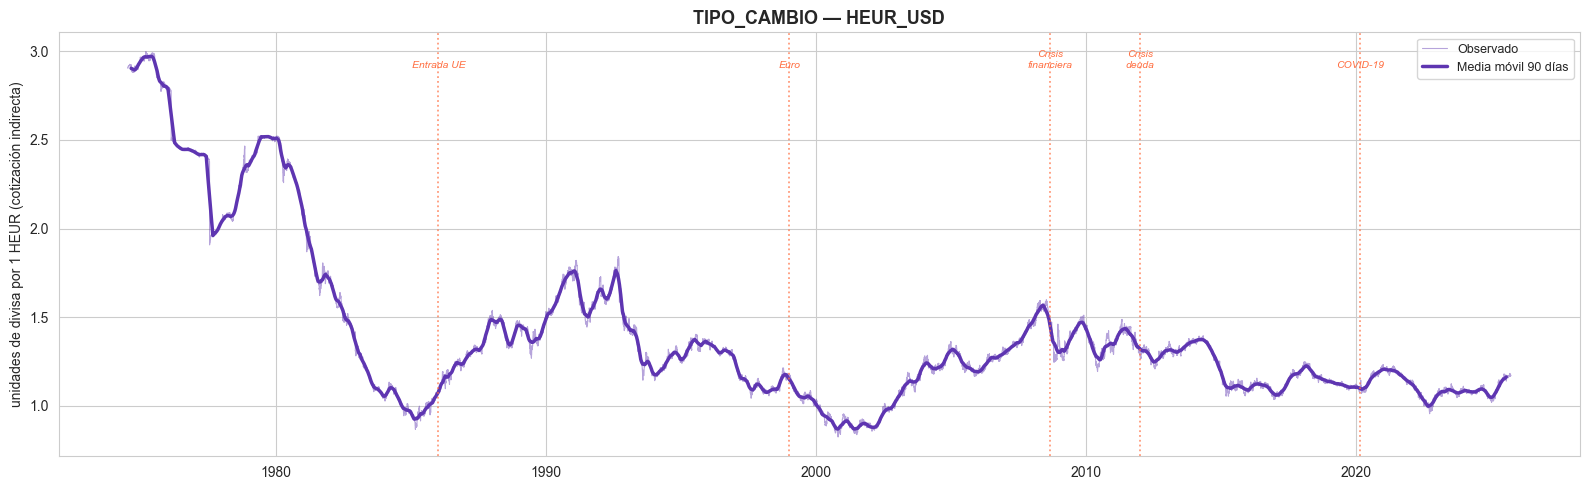

Mín: 0.83  (2000-10-26)
Máx: 3.00  (1975-03-03)


In [38]:
ventana_mm = 90

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil 90 días')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

`HEUR_USD` describe la cotización del euro histórico expresado en dólares por unidad de euro y se caracteriza por la ausencia de tendencia monótona de largo plazo, a diferencia de los índices de precios analizados previamente. Este comportamiento es consustancial a los tipos de cambio nominales bajo regímenes de flotación: la serie no acumula crecimiento de forma acumulativa sino que oscila en torno a niveles que se reajustan según los regímenes monetarios y los diferenciales macroeconómicos entre ambas economías. La serie recorre un máximo de 3,00 en marzo de 1975 y un mínimo de 0,83 en octubre de 2000, casi un factor cuatro de variación, con una estructura claramente cíclica anclada en regímenes monetarios identificables.

El descenso más pronunciado de toda la muestra se produce entre 1975 y 1985, periodo en el que el euro histórico cae desde 3,00 hasta aproximadamente 0,95. Esta depreciación incorpora dos efectos superpuestos: la debilidad inicial del dólar post-Bretton Woods, que situaba al USD en mínimos cíclicos, y la posterior apreciación extrema del dólar bajo la política Volcker de tipos de interés elevados (1980-1984) combinada con la expansión fiscal Reagan. El mínimo local en torno a 0,95 hacia 1985 coincide con el pico de fortaleza del USD que motivó precisamente la intervención coordinada del Plaza Accord en septiembre de 1985.

El ciclo posterior describe una recuperación parcial del euro histórico hasta aproximadamente 1,80 en 1991-1992, impulsada por la depreciación coordinada del USD tras Plaza y la mayor estabilidad de los regímenes monetarios europeos previos a la unión monetaria. La crisis del SME de 1992-1993 y las devaluaciones de la peseta entre 1992 y 1995 producen un descenso moderado hasta aproximadamente 1,15. El segundo gran ciclo bajista lleva la serie hasta su mínimo histórico de 0,83 en octubre de 2000, que refleja la debilidad estructural del euro recién introducido frente a un USD sostenido por el boom tecnológico estadounidense y los flujos de capital hacia los mercados de renta variable de Estados Unidos.

A partir de 2002 la serie inicia una nueva fase alcista hasta aproximadamente 1,55 en 2008, coherente con el deterioro del USD por el déficit corriente acumulado de Estados Unidos y la política expansiva de la Fed en respuesta a la crisis subprime. La crisis de la deuda soberana europea de 2011-2012 contiene la apreciación adicional del euro y a partir de 2014 el programa de expansión cuantitativa del BCE inicia un descenso gradual hasta valores próximos a 1,05-1,15 que se mantienen hasta el final de la muestra, con la única excepción del breve descenso por debajo de 1,00 en 2022 asociado al ciclo de subidas agresivas de tipos de la Fed frente a una respuesta más cauta del BCE.

Para la predicción del paro, el tipo de cambio opera a través de tres canales económicamente relevantes. El turismo internacional procedente de Estados Unidos y zonas dolarizadas se beneficia de un euro débil (`HEUR_USD` bajo), que abarata España como destino y sostiene el empleo en servicios. Las exportaciones fuera de la zona euro mejoran su competitividad con euro débil, afectando al empleo industrial. El coste de la energía importada, denominada en USD, depende inversamente del nivel del euro: un euro fuerte abarata las importaciones de petróleo y reduce la presión inflacionista por costes, con efectos indirectos sobre la inflación y la política monetaria que pueden afectar al empleo. El comportamiento mean-reverting de la serie en torno a regímenes de medio plazo, sin tendencia monótona global, anticipa que el nivel del tipo de cambio puede ser informativo sin necesidad de transformación drástica, aunque la modelización formal requerirá la verificación de estacionariedad y el tratamiento del cambio de régimen estructural en torno a 1985 y 2000.

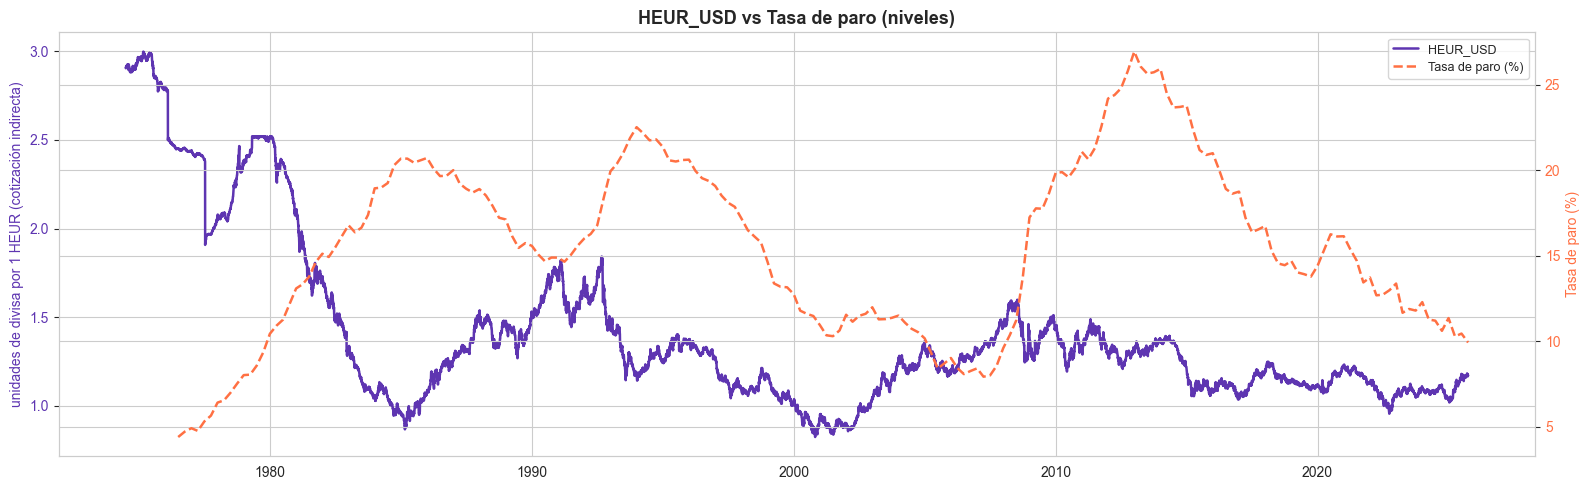

In [39]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación en niveles entre el `HEUR_USD` y la tasa de paro no presenta un signo contemporáneo estable, sino que alterna según el régimen cambiario y macroeconómico. A diferencia de los índices de precios, el `HEUR_USD` carece de tendencia monótona, de modo que la lectura conjunta no está dominada por una deriva común sino por la coincidencia o no de sus respectivos ciclos. Entre 1976 y 1985 ambas series se mueven en sentido inverso: el euro histórico se deprecia desde aproximadamente 2,9 hasta cerca de 0,95 mientras el paro asciende del 5% al 21%, una relación coherente con el encarecimiento de las importaciones energéticas denominadas en dólares, si bien en ese tramo ambas variables responden sobre todo a causas comunes de la transición (inflación, reconversión industrial) más que a un mecanismo directo de transmisión.

Entre 1985 y 2000 la relación es más ambigua: el euro histórico se recupera hasta aproximadamente 1,85 en 1992 mientras el paro sigue subiendo hacia el pico del 24% en 1994, y ambos descienden después durante la recuperación de 1995-1999. Desde 2000 reaparece la relación inversa: el `HEUR_USD` sube desde su mínimo histórico de 0,83 hasta aproximadamente 1,55 en 2008 mientras el paro baja del 14% al 8%, y a partir de 2008 el euro se deprecia gradualmente mientras el paro escala hasta el 27% en 2013. El tramo final muestra un euro débil, en torno a 1,1, conviviendo con un paro a la baja hasta el 10%, coherente con el efecto amortiguador de los ERTEs. El signo cambiante a lo largo de la muestra anticipa una correlación condicionada al régimen, que el análisis cuantitativo de la sección 9 cuantifica sobre la forma estacionaria.

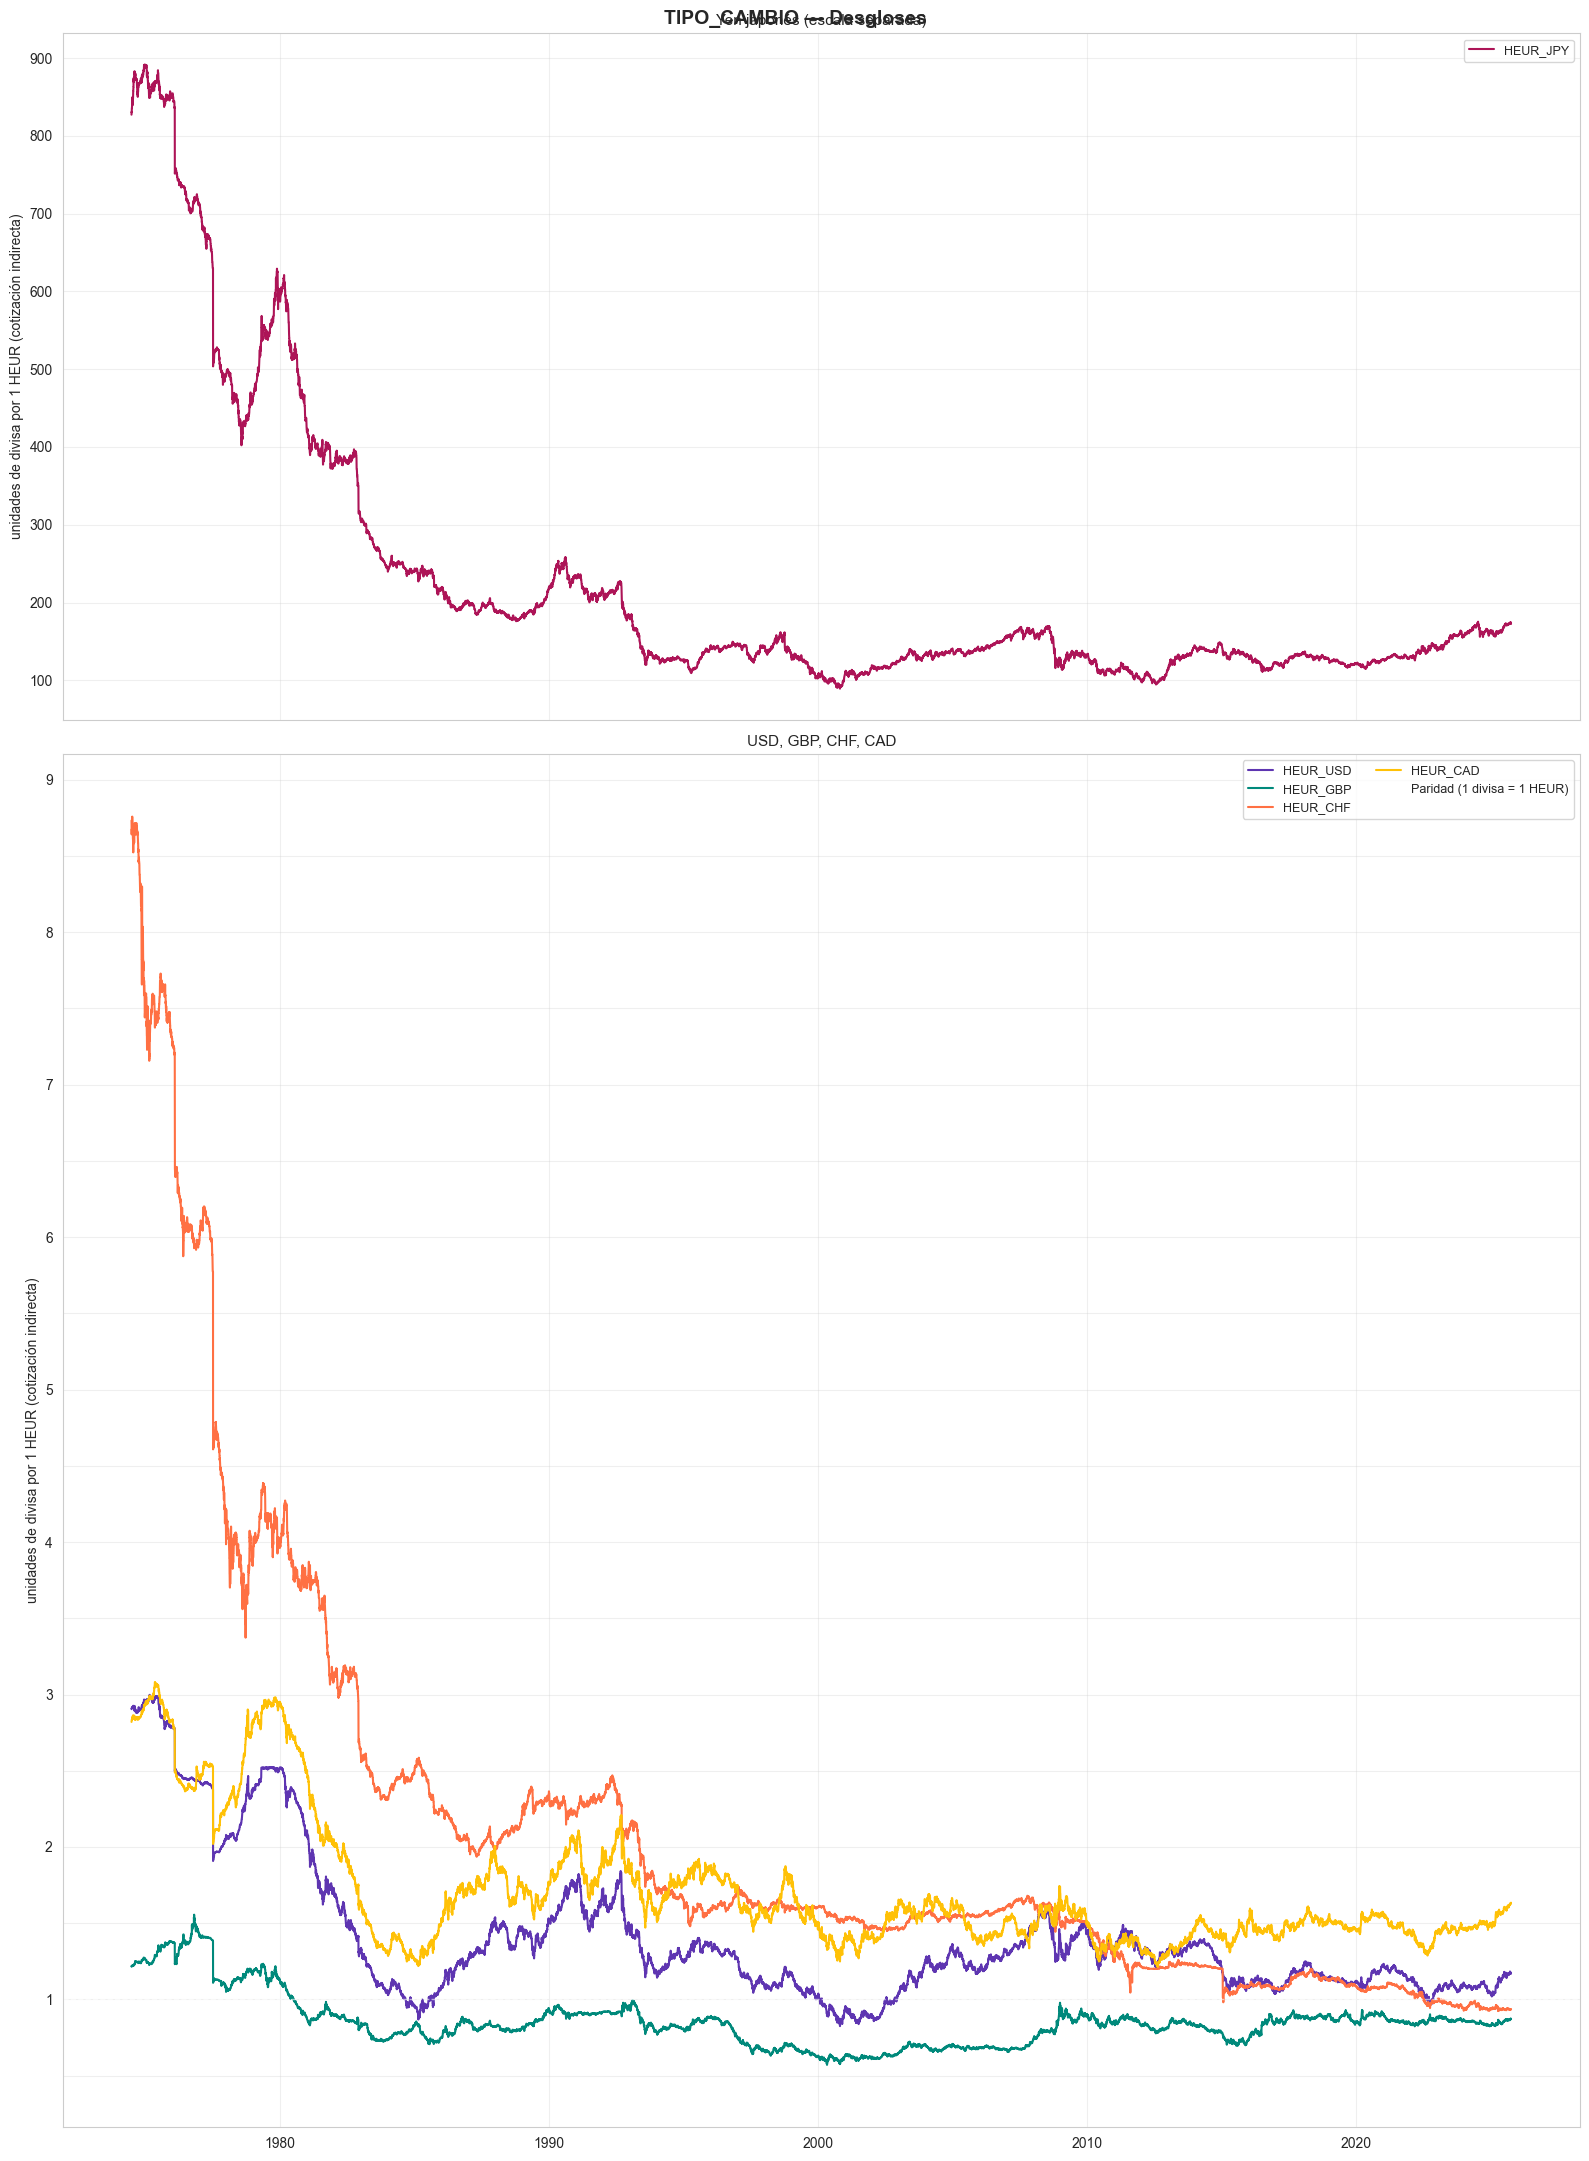

In [40]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    todas = [VAR_PRINCIPAL] + desgloses
    jpy_cols = [c for c in todas if 'JPY' in c]
    otras_cols = [c for c in todas if c not in jpy_cols]

    fig, axes = plt.subplots(2, 1, figsize=(16, 22), sharex=True,
                             gridspec_kw={'height_ratios': [1, 2]})
    fig.suptitle(f'{NOMBRE.upper()} — Desgloses', fontsize=14, fontweight='bold')

    # Panel superior: JPY (lineal, ticks cada 100)
    for col, color in zip(jpy_cols, ['#AD1457']):
        serie = df[col].dropna()
        axes[0].plot(serie.index, serie, color=color, lw=1.5, label=col)
    axes[0].set_ylabel(UNIDADES, fontsize=10)
    axes[0].legend(fontsize=9, loc='upper right')
    axes[0].set_title('Yen japonés (escala separada)', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].yaxis.set_major_locator(plt.MultipleLocator(100))
    axes[0].yaxis.set_minor_locator(plt.MultipleLocator(50))

    # Panel inferior: USD, GBP, CHF, CAD (lineal, ticks de 1 en 1)
    colores_otras = [COLOR_PRINCIPAL] + COLORES_DESGLOSES
    for col, color in zip(otras_cols, colores_otras):
        serie = df[col].dropna()
        axes[1].plot(serie.index, serie, color=color, lw=1.5, label=col)
    axes[1].axhline(1.0, color='white', lw=1.0, linestyle='--', alpha=0.6,
                    label='Paridad (1 divisa = 1 HEUR)')
    axes[1].set_ylabel(UNIDADES, fontsize=10)
    axes[1].legend(fontsize=9, loc='upper right', ncol=2)
    axes[1].set_title('USD, GBP, CHF, CAD', fontsize=11)
    axes[1].grid(True, alpha=0.3, which='both')
    axes[1].yaxis.set_major_locator(plt.MultipleLocator(1))
    axes[1].yaxis.set_minor_locator(plt.MultipleLocator(0.5))

    plt.tight_layout()
    plt.show()

### Análisis:

El desglose por divisas confirma que la depreciación dramática del periodo 1975-1985 documentada para `HEUR_USD` no es específica del dólar sino que refleja una debilidad estructural de la peseta convertida a euro histórico frente a todas las principales divisas. La separación en dos paneles responde a la asimetría de escalas: el yen japonés cotiza en niveles de cientos por unidad de euro mientras el resto se mueve en una banda de 0,5 a 9, y permite además distinguir con precisión qué divisas se sitúan por encima o por debajo de la paridad.

El `HEUR_JPY` describe la depreciación más extrema de toda la muestra: cae desde aproximadamente 900 en 1975 hasta valores cercanos a 100-130 entre los años 90 y la década de 2010, casi un factor 9 de pérdida acumulada que refleja la apreciación estructural del yen característica del despegue exportador japonés. El ciclo reciente de debilidad del yen, con alza hasta aproximadamente 170 en 2024-2025, responde a la divergencia entre la política monetaria ultra-laxa del Banco de Japón y las subidas de tipos del BCE y la Fed.

En el panel inferior, el `HEUR_CHF` parte de aproximadamente 8,7 en 1975 y describe el descenso más pronunciado, cruzando la paridad en torno a 2011-2015 y situándose actualmente por debajo de 1 (aproximadamente 0,95). El franco suizo es la única divisa del grupo cuya fortaleza estructural ha invertido la relación inicial con el euro histórico, coherente con su papel de activo refugio y con la eliminación del suelo EUR/CHF por el Banco Nacional Suizo en enero de 2015. El `HEUR_GBP` describe la trayectoria opuesta: se sitúa por debajo de la paridad durante prácticamente toda la muestra con valores típicos entre 0,65 y 0,90, con breves repuntes en momentos de estrés de la libra (salida del SME en 1992, crisis de 2008-2009, Brexit en 2016, ciclo inflacionista de 2022-2023). El `HEUR_CAD` permanece siempre por encima de la paridad, oscilando entre 1,3 y 2,5 con descenso gradual hasta valores próximos a 1,55, con menor volatilidad por su vinculación al ciclo de materias primas. El `HEUR_USD` ocupa una posición intermedia, oscilando en torno a la paridad sin desviaciones extremas en el largo plazo.

Para la predicción del paro, los canales económicos relevantes operan principalmente a través del USD (energía, materias primas, capital global), la GBP (turismo británico, principal mercado emisor histórico hacia España) y, en menor medida, el CHF como indicador de aversión global al riesgo. La fuerte correlación entre las cinco series durante 1975-1985 limita el aporte informativo marginal de incluir varias divisas como regresores en ese subperiodo, mientras que la divergencia posterior justifica la diversificación cambiaria desde mediados de los 80.

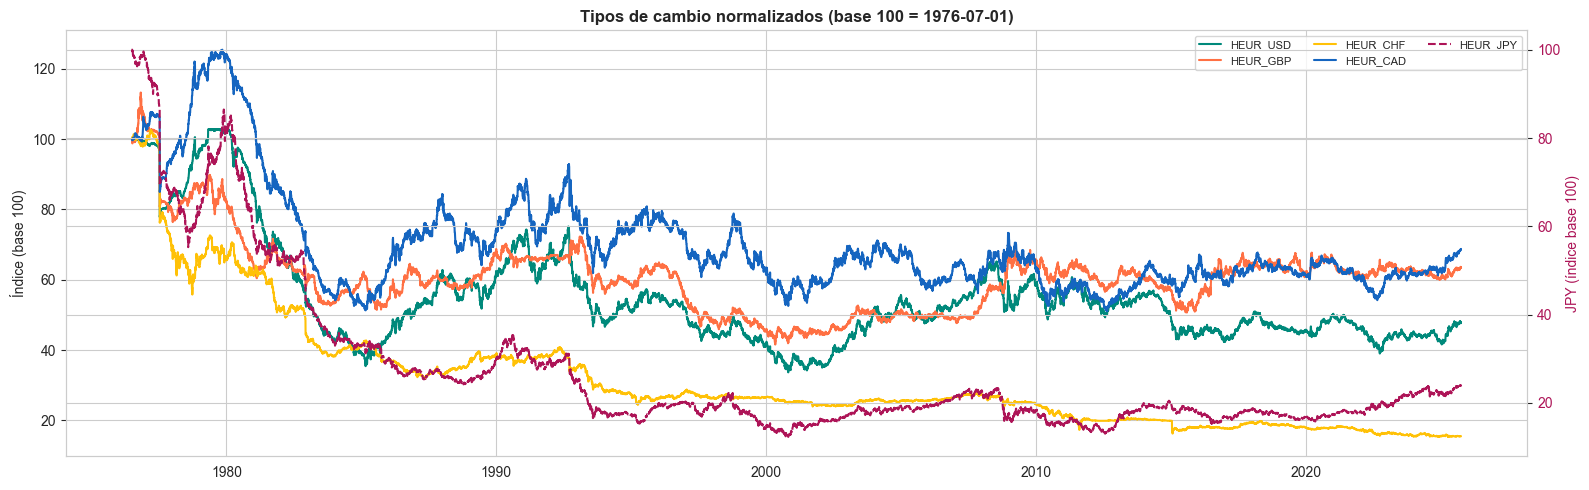

In [41]:
# Divisas normalizadas a 100 en fecha común
divisas = ['HEUR_USD', 'HEUR_GBP', 'HEUR_CHF', 'HEUR_CAD', 'HEUR_JPY']
divisas_disp = [c for c in divisas if c in df.columns]

FECHA_BASE = '1976-07-01'
df_rango = df.loc[FECHA_BASE:][divisas_disp].dropna()
df_norm = df_rango / df_rango.iloc[0] * 100

fig, ax1 = plt.subplots(figsize=(16, 5))
for col, color in zip([c for c in divisas_disp if c != 'HEUR_JPY'], COLORES_DESGLOSES):
    ax1.plot(df_norm.index, df_norm[col], color=color, lw=1.5, label=col)

if 'HEUR_JPY' in divisas_disp:
    ax2 = ax1.twinx()
    ax2.plot(df_norm.index, df_norm['HEUR_JPY'], color='#AD1457', lw=1.5, linestyle='--', label='HEUR_JPY')
    ax2.set_ylabel('JPY (índice base 100)', color='#AD1457', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='#AD1457')
    lines2, labels2 = ax2.get_legend_handles_labels()
else:
    lines2, labels2 = [], []

ax1.set_title(f'Tipos de cambio normalizados (base 100 = {FECHA_BASE})', fontsize=12, fontweight='bold')
ax1.set_ylabel('Índice (base 100)', fontsize=10)
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

### Análisis:

La normalización con base 100 en julio de 1976 elimina las diferencias de escala absoluta entre divisas y permite ordenar con precisión la magnitud relativa de la depreciación del euro histórico frente a cada una desde el inicio de la muestra. La estructura visual revela cinco trayectorias claramente diferenciadas con una jerarquía estable de fortaleza relativa.

El `HEUR_CHF` describe la pérdida acumulada más extrema, cerrando la muestra en torno a 15-18 puntos sobre la base 100. El franco suizo se ha apreciado aproximadamente un 85% frente al euro histórico desde 1976, una magnitud sin equivalente en el resto del grupo y consistente con su papel estructural como activo refugio durante los episodios de estrés financiero internacional. El `HEUR_JPY` ocupa el segundo lugar con valores próximos a 25-30 al final de la muestra (apreciación japonesa de aproximadamente 70-75%), aunque el repunte reciente desde valores mínimos cercanos a 18 en 2012 marca una inflexión: el yen ha perdido fortaleza relativa en los últimos años debido al diferencial creciente de tipos con BCE y Fed.

Las tres divisas restantes se sitúan en una banda intermedia de menor depreciación acumulada. El `HEUR_USD` y el `HEUR_GBP` cierran la muestra en torno a 45-65 (apreciación del 35-55% del USD y la GBP frente al euro histórico), con trayectorias que se cruzan en varios puntos sin diferencia sistemática de largo plazo. El `HEUR_CAD` muestra la menor depreciación del grupo, cerrando próximo a 70 (apreciación del CAD de apenas un 30%), consistente con el comportamiento más amortiguado de los tipos de cambio de divisas commodity vinculadas al ciclo de materias primas.

El patrón común a las cinco series es la pérdida acelerada del 60-70% de su valor entre 1976 y 1985, seguida de divergencias específicas a cada divisa a partir de 1985. Esta cohesión inicial confirma que el periodo de transición y reconversión productiva española produjo un debilitamiento generalizado de la peseta-euro histórico frente al conjunto de divisas internacionales, mientras que la evolución posterior queda condicionada por la política monetaria y la balanza de pagos específicas de cada par bilateral.

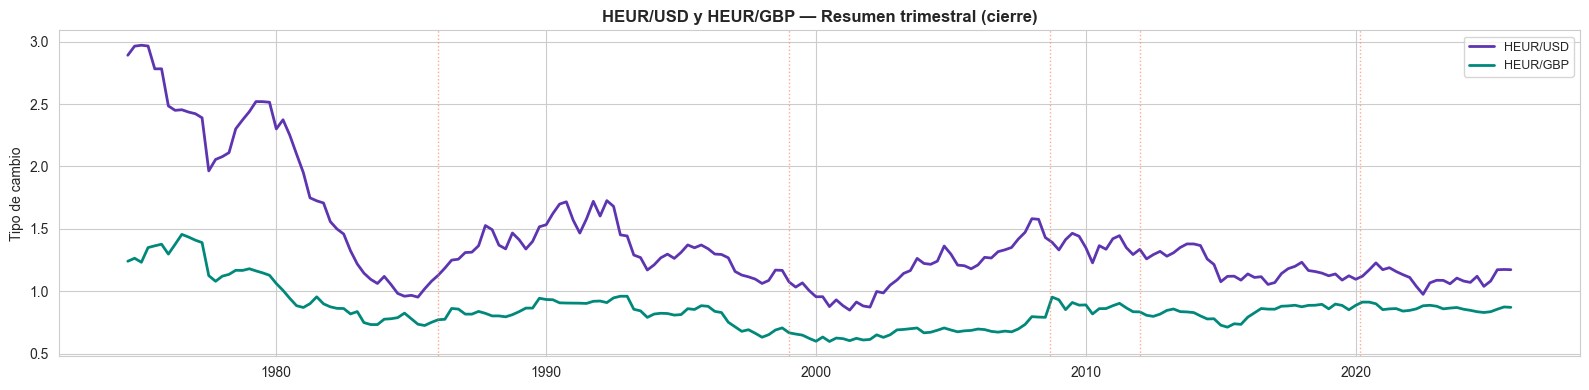

In [42]:
# Resumen trimestral para visión de largo plazo
df_q = df[['HEUR_USD', 'HEUR_GBP']].resample('QS').last().dropna()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_q.index, df_q['HEUR_USD'], color=COLOR_PRINCIPAL, lw=2, label='HEUR/USD')
ax.plot(df_q.index, df_q['HEUR_GBP'], color='#00897B', lw=2, label='HEUR/GBP')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if df_q.index.min() <= fecha_ev <= df_q.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1, alpha=0.6)

ax.set_title('HEUR/USD y HEUR/GBP — Resumen trimestral (cierre)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tipo de cambio', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Análisis:

El resumen trimestral por cierre confirma que el resampleo no distorsiona la estructura cíclica de ninguna de las dos series y mantiene intactos los puntos de inflexión identificados en el análisis diario. La comparación directa entre `HEUR/USD` y `HEUR/GBP`, las dos divisas más relevantes para la economía española, revela diferencias sustanciales de amplitud y volatilidad que justifican un tratamiento diferenciado en la modelización.

`HEUR/USD` describe una serie de mayor amplitud, recorriendo desde el máximo histórico de aproximadamente 2,95 en 1975 hasta el mínimo de 0,85 en 2000 y oscilando entre 0,85 y 1,70 durante toda la etapa post-1985. La amplitud cíclica posterior a la transición es de aproximadamente 0,85 puntos. `HEUR/GBP`, en cambio, se mueve en una banda mucho más estrecha de 0,55 a 0,95 desde 1985, con una amplitud cíclica de apenas 0,40 puntos, prácticamente la mitad de la observada para el dólar.

Los puntos de inflexión de ambas series están razonablemente sincronizados pero no son idénticos. El máximo de 1992 en `HEUR/USD` (1,70) coincide con un máximo local en `HEUR/GBP` (0,95), y el mínimo de 2000 en USD (0,85) coincide con el mínimo histórico de GBP (0,65). Sin embargo, el segundo ciclo alcista del USD (máximo 2008 en 1,55) no se reproduce con la misma intensidad en GBP, que permanece en una banda 0,75-0,95 durante todo ese periodo, reflejando que la apreciación de la libra frente al dólar se transmitió parcialmente al euro histórico.

Para la modelización del paro, la menor amplitud de `HEUR/GBP` implica que su contribución como regresor estará probablemente más ligada a su nivel medio (que define el coste relativo de viajar a España para el turista británico) que a su volatilidad, mientras que `HEUR/USD` aporta señal tanto por nivel (coste energético, competitividad exportadora) como por movimientos cíclicos. La verificación formal de estacionariedad sobre estas series trimestrales se realizará en la siguiente sección.

---
## 3. Distribución y Outliers

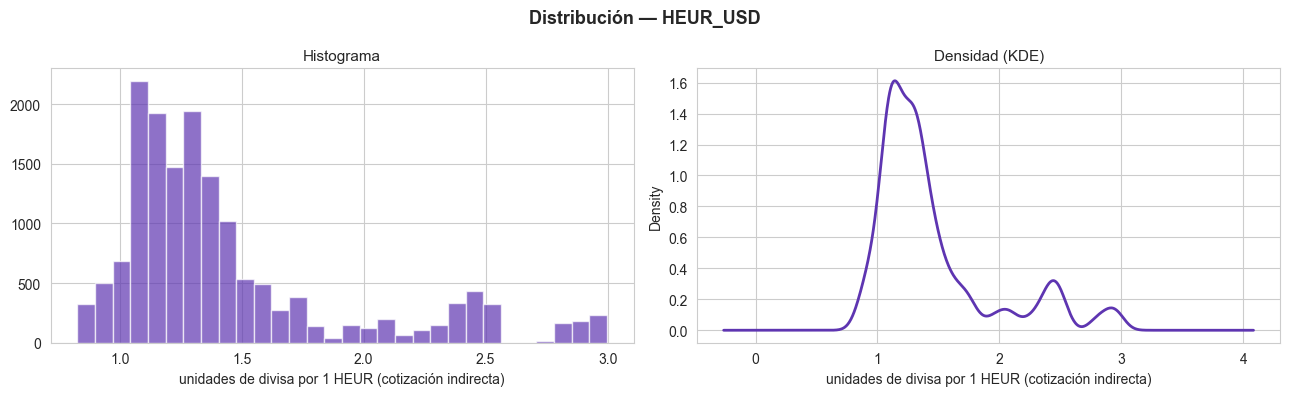

Asimetría (skewness): 1.571
Curtosis:             1.665


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

`HEUR_USD` presenta una distribución marcadamente asimétrica hacia la derecha con un cuerpo principal concentrado entre 0,85 y 1,55 y una cola derecha extendida hasta el máximo histórico de 3,00 que incluye varios subclusters discernibles. La asimetría positiva de 1,571 y la curtosis de 1,665 cuantifican esta forma: ambas son sustancialmente más elevadas que las observadas en `IPRI_total_industria_2025` (0,405 y -0,023 respectivamente), lo que refleja que el `HEUR_USD` no es simplemente una serie con tendencia, sino una serie con un cambio de régimen estructural que produce dos masas de observaciones cuantitativamente diferenciadas.

El cuerpo principal entre 0,85 y 1,55 concentra la práctica totalidad de las observaciones del régimen post-1985, cuando el tipo de cambio oscila de forma mean-reverting alrededor de niveles próximos a la paridad. Dentro de este cuerpo se distinguen dos máximos locales, uno en torno a 1,05-1,10 y otro en torno a 1,25-1,30, que el KDE agrega en un único pico amplio. Estos dos modos internos corresponden a los dos regímenes de fortaleza cíclica del USD (mínimos de 2000 y 2014-2022) y de fortaleza relativa del euro (máximos de 2008), respectivamente.

La cola derecha entre 1,55 y 3,00 concentra las observaciones del periodo 1975-1985 documentadas en el análisis de la serie principal. El cluster visible en torno a 2,4-2,5 corresponde a los años 1979-1982, mientras que el cluster en torno a 2,9-3,0 recoge el tramo inicial 1975-1976 de máxima debilidad de la peseta. Estos subclusters no son outliers estadísticos en el sentido habitual sino segmentos temporales de un régimen estructuralmente distinto del actual, lo que confirma que la serie no admite un tratamiento estacionario homogéneo sobre toda la muestra en su nivel. El cambio de régimen estructural queda documentado como una característica de la serie, cuyo tratamiento se difiere a las fases de feature engineering y modelización.

In [44]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 1996
Outliers por z-score (>3): 300

10 valores extremos (5 mínimos + 5 máximos):
     fecha  valor
2000-10-26  0.825
2000-10-25  0.831
2000-10-27  0.832
2000-10-23  0.838
2001-07-06  0.838
1975-02-28  2.991
1975-03-01  2.991
1975-03-06  2.993
1975-03-04  2.995
1975-03-03  2.998


### Análisis:

El `HEUR_USD` presenta 1.996 outliers por criterio IQR (1,5×) y 300 por z-score (>3), un contraste radical con la ausencia total de outliers del `IPRI_total_industria_2025`. La diferencia no refleja anomalías estadísticas en sentido estricto sino la estructura por regímenes de la serie: el cuerpo principal post-1985 se concentra entre 0,85 y 1,55, y las observaciones del régimen pre-1985, con valores de hasta 3,00, quedan sistemáticamente fuera de los bigotes del cuerpo principal. Que el criterio IQR marque aproximadamente el 13% de la muestra como extrema indica que el periodo pre-1985 no es un episodio marginal sino un segmento temporal de un régimen cambiario estructuralmente distinto.

Los diez valores extremos confirman esta lectura: los cinco mínimos se concentran en octubre de 2000 y julio de 2001 (entre 0,825 y 0,838), el mínimo histórico de fortaleza del dólar durante el boom tecnológico estadounidense, y los cinco máximos en febrero y marzo de 1975 (entre 2,991 y 2,998), el tramo inicial de máxima debilidad de la peseta tras el fin de Bretton Woods. Ambos grupos son extremos temporales de regímenes diferenciados, no perturbaciones puntuales, lo que confirma que la serie no admite un tratamiento estacionario homogéneo sobre toda la muestra en su nivel.

In [45]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

La distribución por mes del `HEUR_USD` no presenta patrón estacional alguno. Las 12 cajas son prácticamente idénticas en mediana (en torno a 1,30), rango intercuartílico (aproximadamente 1,00-1,50) y extensión de bigotes (hasta aproximadamente 2,00). Los outliers que aparecen por encima de los bigotes en todos los meses, agrupados en dos bandas (2,3-2,5 y 2,8-3,0), corresponden a las observaciones del régimen pre-1985 ya identificadas en el análisis de distribución y se distribuyen de forma homogénea a lo largo del año, confirmando que no son artefactos estacionales sino segmentos temporales de un régimen cambiario estructuralmente diferente.

Este resultado es esperable para un tipo de cambio bilateral entre divisas de economías desarrolladas: los movimientos cambiarios responden a diferenciales de tipos de interés, flujos de capital y expectativas macroeconómicas que no siguen un calendario mensual recurrente. A diferencia de variables como el empleo (con estacionalidad turística en T3) o los precios al consumo (con actualización de tarifas reguladas en enero), el `HEUR_USD` carece de mecanismo económico que genere un patrón mensual sistemático. Para la modelización, el resampleo a frecuencia trimestral mediante media no eliminará ni creará variación estacional artificial, y no se requiere corrección estacional previa.

---
## 4. Estacionalidad

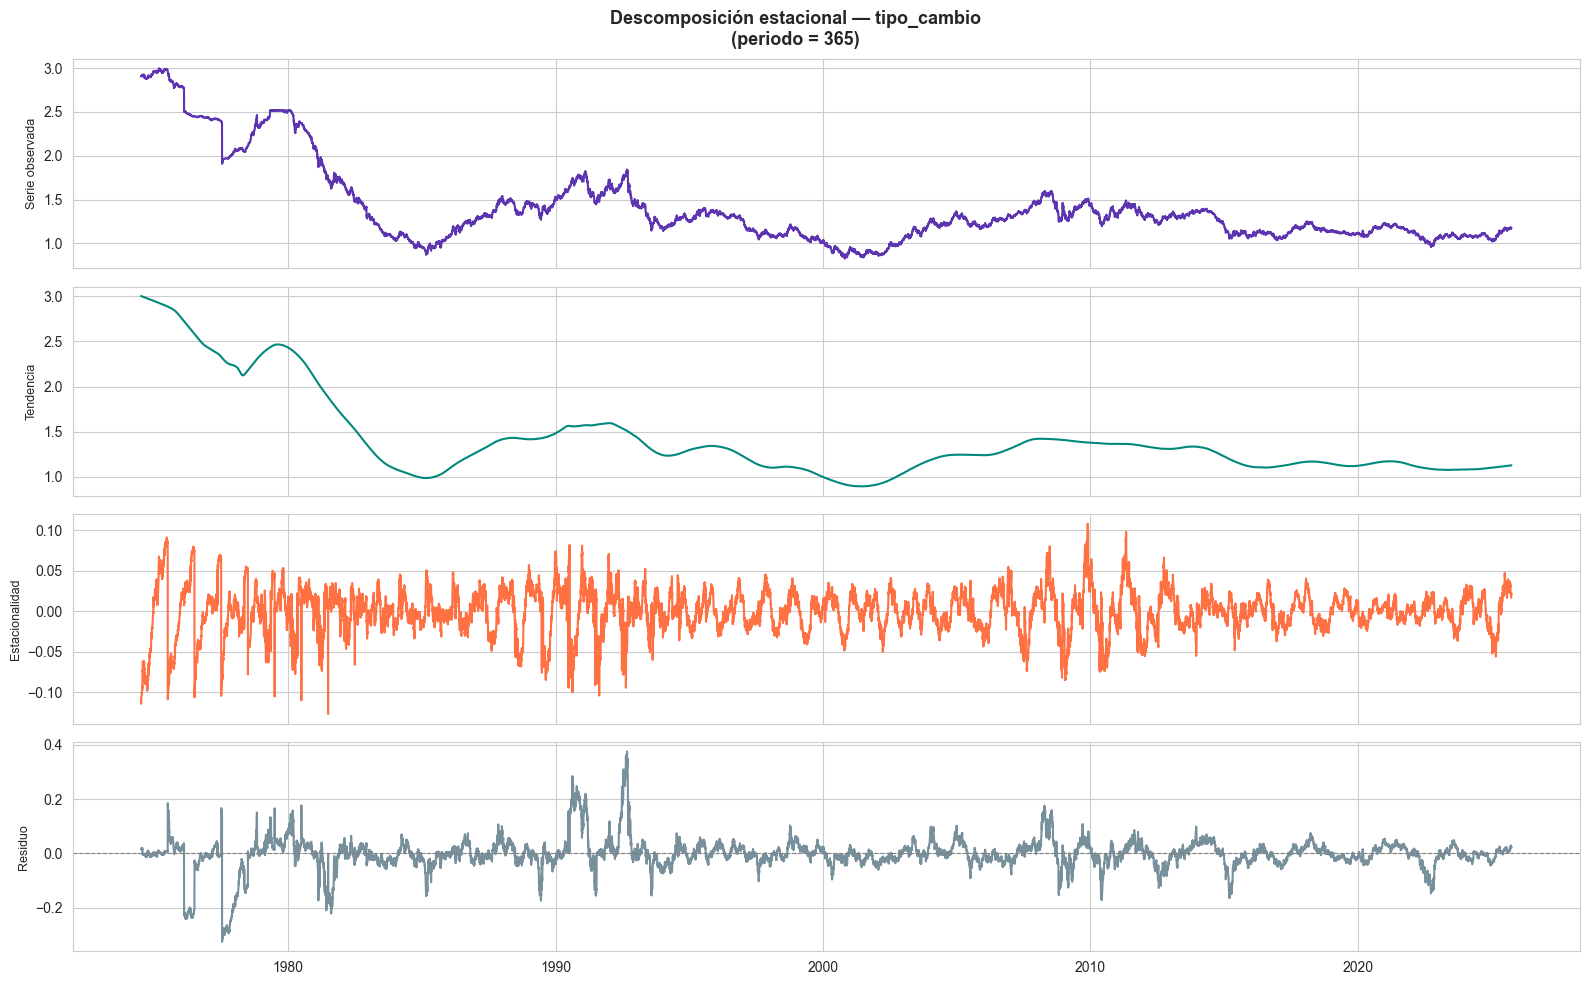

In [46]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    stl = STL(y_descomp, period=365, robust=True)
    descomp = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición STL con periodo 365 confirma cuantitativamente lo anticipado por el boxplot mensual: el `HEUR_USD` no presenta estacionalidad anual económicamente relevante. La amplitud del componente estacional oscila entre aproximadamente -0,10 y +0,10 a lo largo de la muestra, lo que sobre una serie que recorre valores de 0,83 a 3,00 representa una fracción reducida del nivel medio y carece de patrón sistemático interpretable. Como ya se documentó para los precios industriales, los mecanismos económicos que generan estacionalidad en variables reales (calendario laboral, ciclos turísticos, actualización de tarifas reguladas) no operan sobre tipos de cambio entre divisas de economías desarrolladas.

La tendencia captura prácticamente la totalidad de la dinámica relevante de la serie: el descenso pronunciado desde aproximadamente 3,00 en 1975 hasta el mínimo en torno a 0,95 en 1985, la recuperación parcial hasta aproximadamente 1,55 en 1991-1992, el segundo mínimo de 2000-2001 y la oscilación posterior en torno a 1,15-1,40 con una ligera tendencia descendente desde 2008. La suavidad del componente tendencial indica que el filtro absorbe los cambios cíclicos como movimientos de medio plazo, no como perturbaciones transitorias, coherente con la interpretación de la serie como mean-reverting alrededor de regímenes cambiarios sucesivos.

El componente residual revela un patrón claro de heterocedasticidad y clustering de volatilidad. Los periodos 1976-1977 y 1981-1983 concentran residuos negativos de gran magnitud (hasta aproximadamente -0,30), reflejando los movimientos abruptos de la peseta durante la transición y la reconversión industrial. Los años 1990-1993 muestran los residuos positivos más extremos de toda la muestra (hasta aproximadamente +0,40), asociados a las turbulencias del SME y a las devaluaciones de la peseta. Los episodios de 2008-2010 y 2014-2015 producen picos más contenidos. A partir de 2015 los residuos se mantienen en una banda estrecha de ±0,10, indicando una reducción estructural de la volatilidad coherente con la consolidación del régimen del euro. Esta heterocedasticidad con clustering de volatilidad, concentrada en el periodo previo a 2000 y muy reducida desde 2015, queda documentada como una característica de la serie; su tratamiento se difiere a las fases de feature engineering y modelización.

In [47]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

---
## 5. Cambios Periodo a Periodo

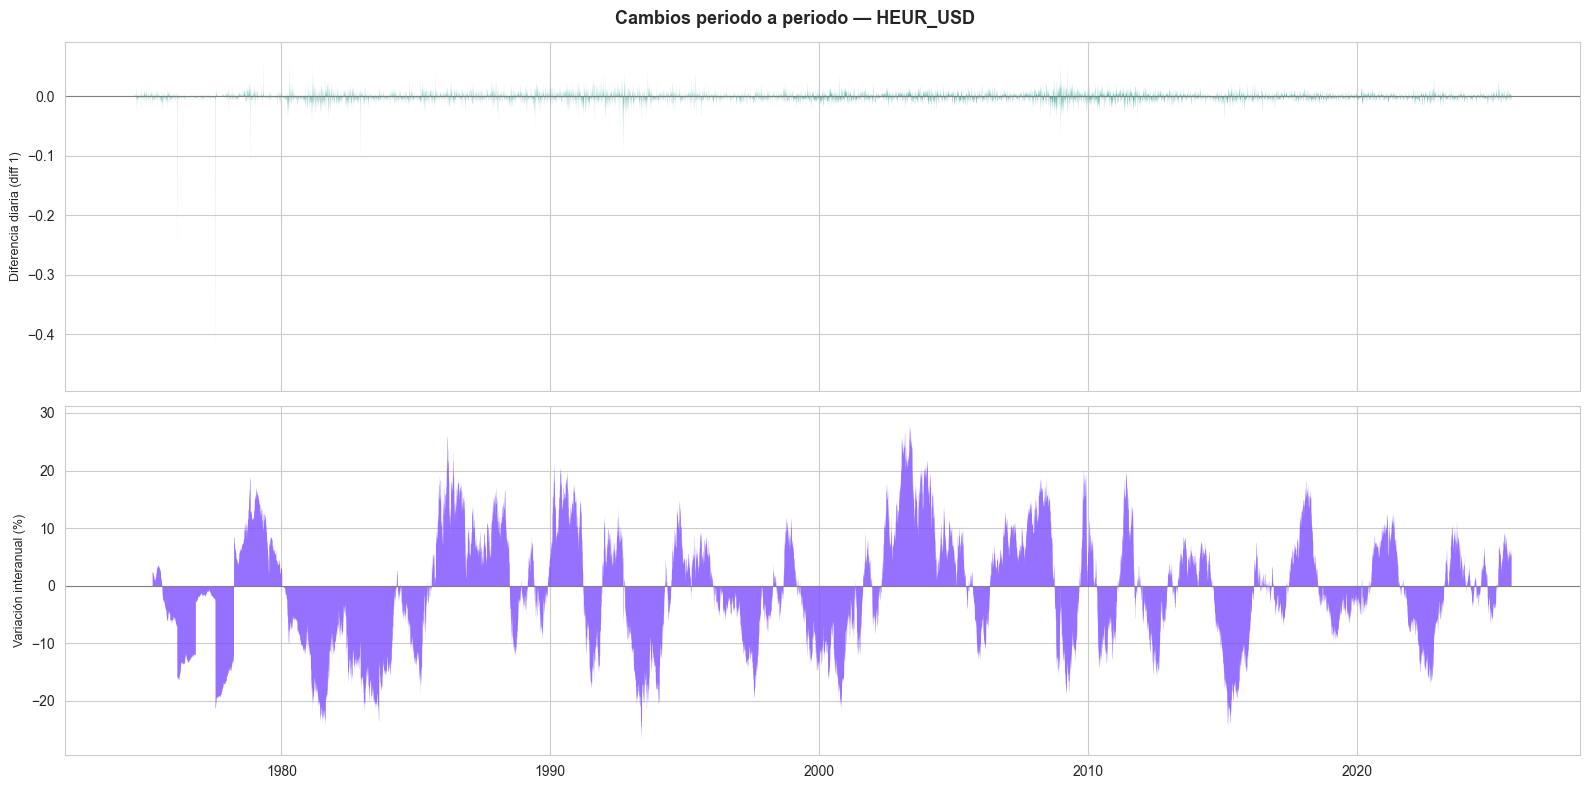

Estadísticas de la variación interanual (%):
count   15548.000
mean       -1.030
std        10.230
min       -26.700
25%        -8.900
50%        -1.390
75%         6.690
max        28.430


In [48]:
diff1 = y.diff(1).dropna()
pct_yoy = y.pct_change(252).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].fill_between(diff1.index, diff1, 0, color='#00897B', alpha=0.8, lw=0)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia diaria (diff 1)', fontsize=9)

axes[1].fill_between(pct_yoy.index, pct_yoy, 0, color='#7C4DFF', alpha=0.8, lw=0)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La diferencia diaria (panel superior) es visualmente indistinguible de ruido blanco a lo largo de toda la muestra, con valores contenidos en una banda extremadamente estrecha en torno a cero. Esta ausencia de estructura visible en la diff 1 diaria es una propiedad canónica de los tipos de cambio entre divisas líquidas: a frecuencia diaria, los cambios son prácticamente impredecibles, coherente con la hipótesis de mercados eficientes en su forma débil.

La variación interanual (panel inferior) ofrece la perspectiva relevante para la modelización trimestral y revela una estructura radicalmente distinta a la observada para el `IPRI_total_industria_2025`. Mientras la variación interanual del IPRI estaba dominada por un único shock extremo (46,97% en 2022), el `HEUR_USD` describe oscilaciones cíclicas recurrentes de amplitud relativamente estable a lo largo de toda la muestra, con un rango entre -26,70% y +28,43% y una desviación típica de 10,23%. La simetría del rango y la proximidad de la media (-1,03%) y la mediana (-1,39%) a cero reflejan la naturaleza mean-reverting de la serie: las apreciaciones y depreciaciones del euro frente al dólar se compensan en el largo plazo, con un sesgo negativo marginal que recoge la depreciación tendencial del euro histórico documentada en la serie principal.

La amplitud de las oscilaciones interanuales no muestra la heterocedasticidad progresiva que caracterizaba al IPRI. Los ciclos de 1977-1980 (-20% a +15%), 1985-1993 (-20% a +25%), 2001-2008 (-15% a +27%) y 2020-2023 (-18% a +15%) son de magnitud comparable, sin que el periodo reciente domine la distribución. Esta estabilidad relativa de la volatilidad interanual es una propiedad favorable para la modelización: sugiere que la variación interanual del `HEUR_USD` puede tratarse como una variable estacionaria con varianza aproximadamente constante a lo largo de la muestra, sin necesidad del tratamiento de régimen diferenciado que exigía el IPRI.

---
## 6. Estacionariedad y Autocorrelación

In [49]:
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()
pct_est = ((y / y.shift(PERIODO_ESTACIONAL) - 1) * 100).dropna()  # variación interanual %

def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'c'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
    (pct_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                      serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           HEUR_USD (nivel)          c    -3.122  0.025            True      9.822   0.010             True NO ESTACIONARIA
          HEUR_USD (diff 1)          c   -35.915  0.000            True      0.448   0.057            False    ESTACIONARIA
        HEUR_USD (diff 365)          c    -3.763  0.003            True      1.549   0.010             True NO ESTACIONARIA
HEUR_USD (var interanual %)          c    -3.800  0.003            True      0.771   0.010             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  HEUR_USD (nivel)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-3.122, p=0.0249 (rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=9.822, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  HEUR_USD (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-35.915, p

### Análisis:

En niveles, los dos tests convergen en un diagnóstico de no estacionariedad pese a un matiz: el ADF rechaza la raíz unitaria (stat=-3,122, p=0,0249) pero el KPSS rechaza con contundencia la estacionariedad (stat=9,822, p=0,0100), un estadístico KPSS extraordinariamente elevado que domina el diagnóstico. La discrepancia se resuelve, por criterio conservador, como no estacionariedad, coherente con el cambio de régimen estructural de la serie: el ADF detecta la reversión local a la media dentro de cada régimen, mientras el KPSS capta la no estacionariedad global que introducen los saltos de nivel entre regímenes.

La primera diferencia diaria produce el diagnóstico más limpio de toda la batería: el ADF rechaza la raíz unitaria de forma extrema (stat=-35,915, p=0,0000) y el KPSS no rechaza la estacionariedad (stat=0,448, p=0,0565), el patrón de ruido blanco propio de un tipo de cambio entre divisas líquidas. Ni la diferencia interanual (diff 365) ni la variación interanual porcentual son estacionarias a frecuencia diaria: en ambas el KPSS rechaza la estacionariedad (stat=1,549 y 0,771 respectivamente, p=0,0100), por la fuerte persistencia que introduce el solapamiento interanual sobre datos diarios. A frecuencia diaria, por tanto, la única transformación estacionaria es la primera diferencia; el comportamiento de las transformaciones interanuales se reevalúa sobre la serie resampleada en el bloque 6.1.

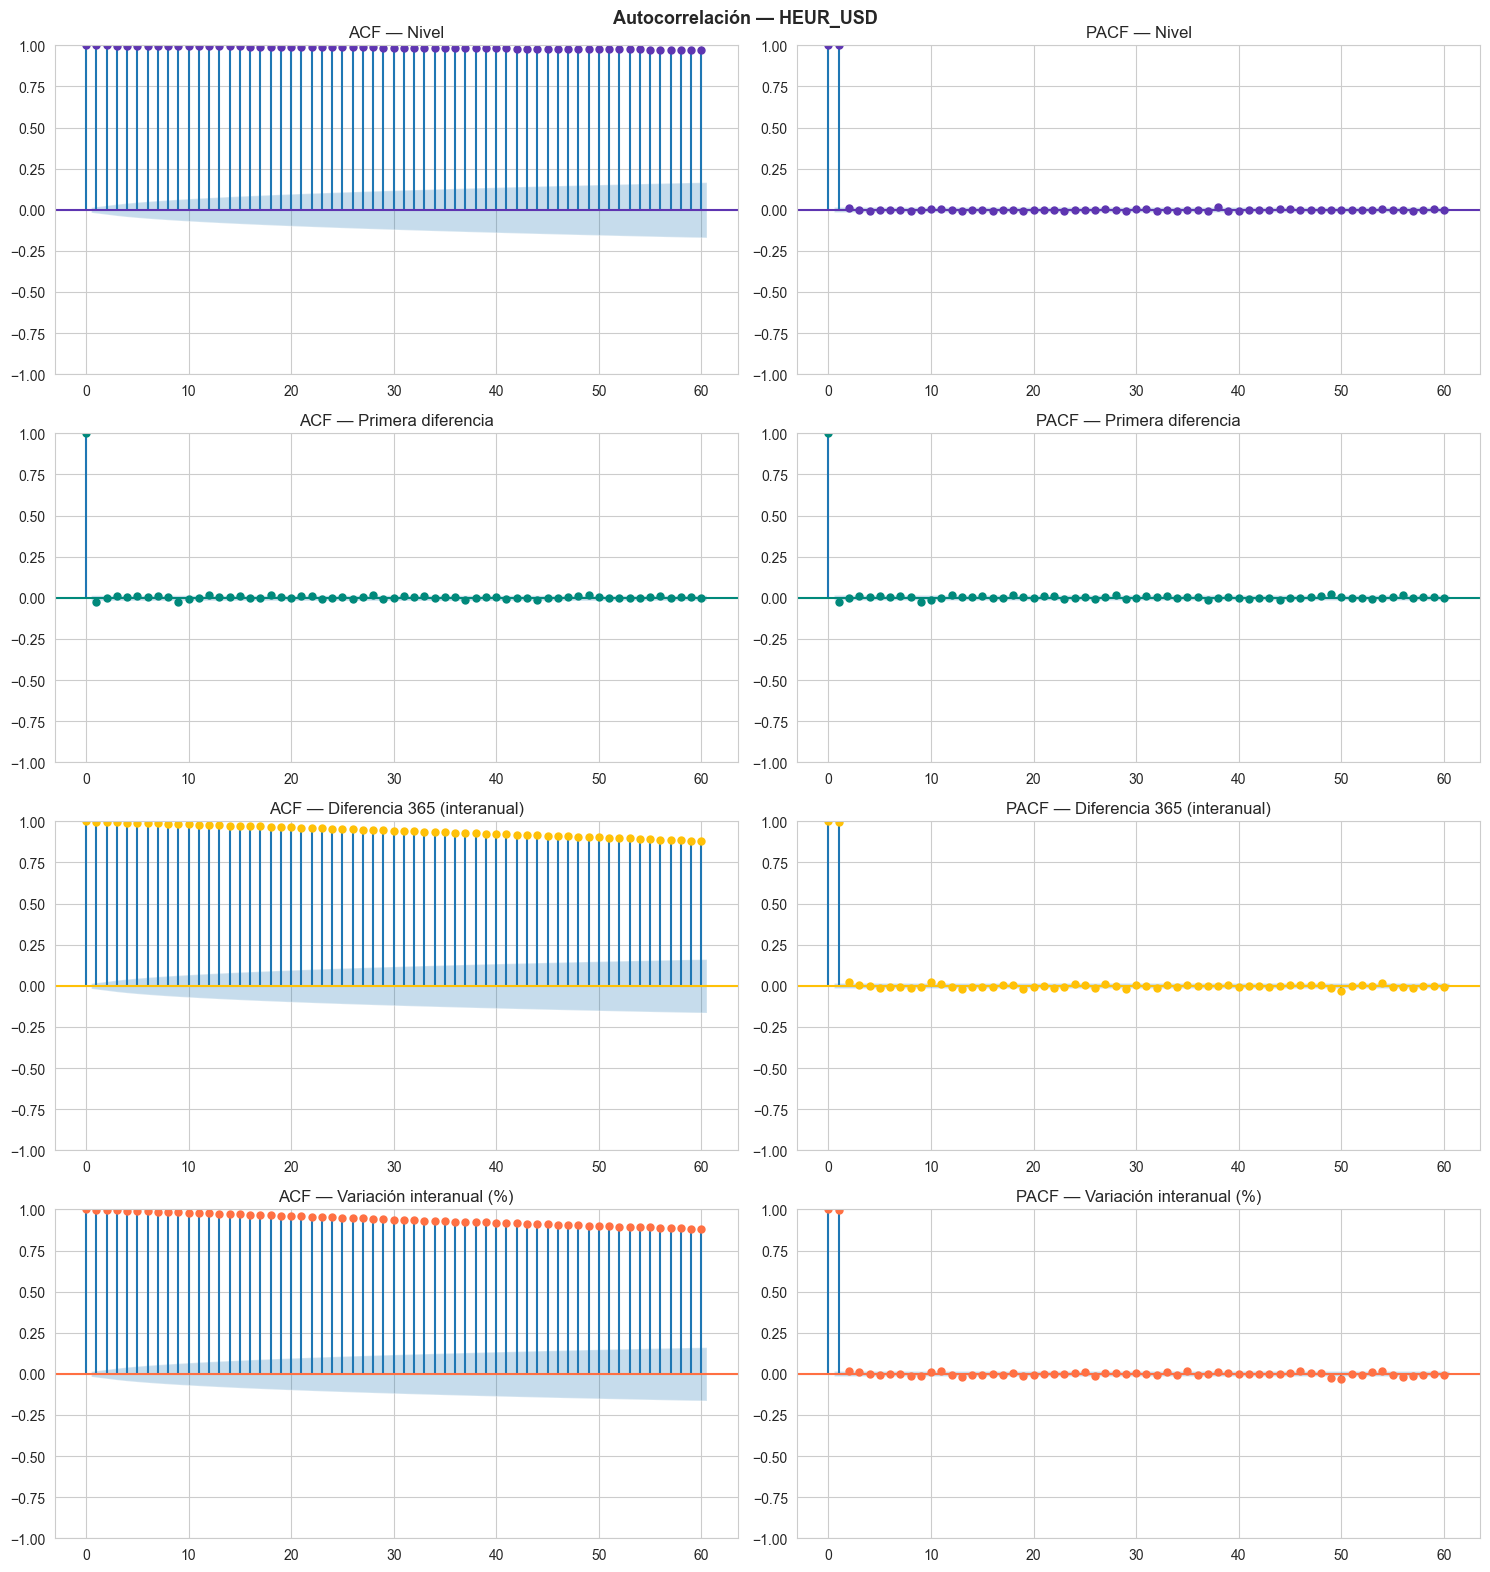

In [50]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title=f'ACF — Diferencia {PERIODO_ESTACIONAL} (interanual)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title=f'PACF — Diferencia {PERIODO_ESTACIONAL} (interanual)', method='ywm')
plot_acf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual (%)')
plot_pacf(pct_est.dropna(), lags=LAGS_ACF, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

El correlograma del `HEUR_USD`, calculado en frecuencia diaria, presenta el patrón más limpio y definido de todos los analizados hasta ahora. En niveles, la ACF no decae en ninguno de los 60 lags representados, manteniéndose próxima a 1,0 a lo largo de todo el espectro, mientras la PACF muestra un único pico dominante en el lag 1 y lags posteriores absolutamente nulos, todos dentro de la banda de significancia. Este patrón, ACF constante y PACF con corte tras el lag 1, es la firma canónica de un proceso autorregresivo de orden 1 con raíz unitaria, más extrema que la observada para el `IPRI_total_industria_2025`, donde la ACF decaía lentamente pero sí decaía.

Tras la primera diferencia diaria el contraste es radical. Tanto la ACF como la PACF caen a valores prácticamente nulos en todos los lags desde el lag 1, sin ningún pico significativo ni estructura residual visible, configurando el patrón de ruido blanco puro. Este resultado es cualitativamente distinto del que presentaba la primera diferencia del IPRI, donde permanecían picos significativos en lags 1, 3 y 5 que apuntaban a un proceso ARMA mixto. La ausencia de estructura autorregresiva en la diff 1 diaria confirma el diagnóstico de no estacionariedad en niveles, pero no informa directamente sobre la especificación del modelo predictivo del paro, que opera en frecuencia trimestral: a esa escala, la capacidad predictiva del tipo de cambio provendrá de la correlación cruzada con la tasa de paro, no de la dinámica propia de la serie.

### 6.1 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por media trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [51]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'media'
y_q = df[VAR_PRINCIPAL].resample('QS').mean().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: media):
                                 serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           HEUR_USD trimestral (nivel)         ct    -3.559  0.007            True      0.273   0.010             True NO ESTACIONARIA
              HEUR_USD trimestral (Δ1)          c    -9.859  0.000            True      0.306   0.100            False    ESTACIONARIA
              HEUR_USD trimestral (Δ4)          c    -3.115  0.025            True      0.330   0.100            False    ESTACIONARIA
HEUR_USD trimestral (var interanual %)          c    -4.070  0.001            True      0.166   0.100            False    ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  HEUR_USD trimestral (nivel)  (KPSS regression='ct')
    ADF  stat=-3.559, p=0.0066 (rechaza H₀)
    KPSS stat=0.273, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  HEUR_USD trimestral (Δ1)

### Análisis:

La validación a frecuencia trimestral confirma y amplía el diagnóstico de la frecuencia diaria. El nivel sigue siendo no estacionario, ahora con ambos tests convergentes (el ADF rechaza la raíz unitaria con stat=-3,559, p=0,0066, pero el KPSS rechaza la estacionariedad con stat=0,273, p=0,0100), de nuevo por el cambio de régimen estructural que el KPSS detecta. La primera diferencia `Δ1` es estacionaria con holgura (ADF stat=-9,859, p=0,0000; KPSS stat=0,306, p=0,1000), la transformación más limpia también a esta frecuencia.

La diferencia respecto al bloque diario está en las transformaciones interanuales. Mientras a frecuencia diaria la diff 365 y la variación interanual porcentual eran no estacionarias, a frecuencia trimestral tanto la `Δ4` (ADF stat=-3,115, p=0,0255; KPSS stat=0,330, p=0,1000) como la variación interanual porcentual (ADF stat=-4,070, p=0,0011; KPSS stat=0,166, p=0,1000) resultan estacionarias. El cambio de diagnóstico es metodológico, no del proceso: el resampleo por media suaviza la varianza residual y reduce la persistencia del solapamiento interanual, de modo que las propiedades del proceso no cambian al resamplear, cambia la capacidad de los tests para distinguirlas. El cuadro trimestral deja así tres formas estacionarias disponibles (`Δ1`, `Δ4` y variación interanual %), de las cuales `Δ1` es la más robusta y la adoptada para el cruce con el paro.

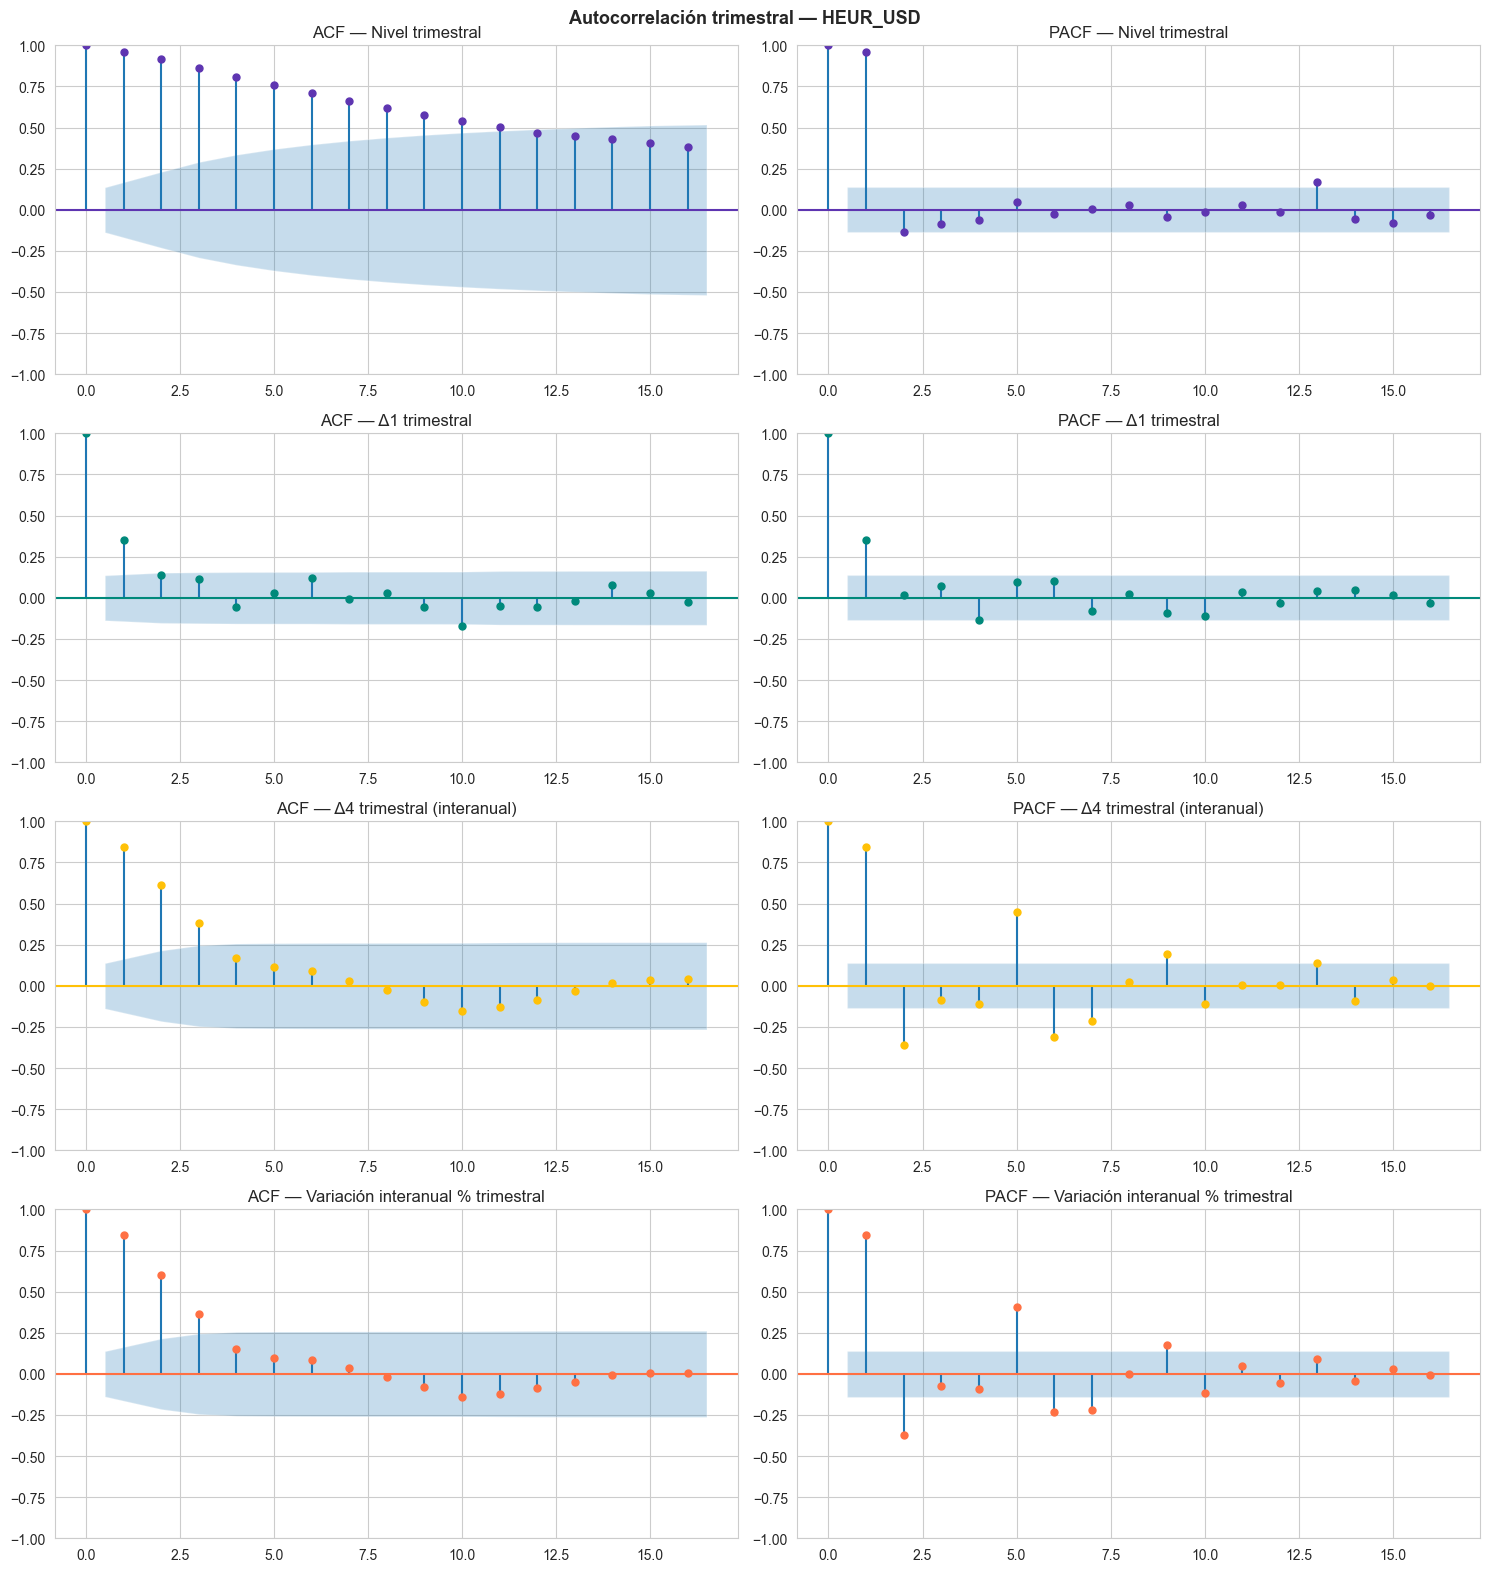

In [52]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

La estructura de autocorrelación a frecuencia trimestral confirma el patrón de los tests y replica a menor resolución el del bloque diario. En nivel, la ACF decae lentamente desde valores próximos a 1 (en torno a 0,40 todavía en el lag 16) y la PACF concentra toda la señal en un pico dominante en el lag 1 cercano a la unidad, la firma canónica de un AR(1) con raíz próxima a 1 propia de una serie no estacionaria.

La primera diferencia `Δ1` es la transformación más próxima al ruido blanco: la ACF muestra un único pico modesto en el lag 1 (aproximadamente 0,35) y entra en banda a partir del lag 2, y la PACF replica ese perfil, sin estructura estacional en múltiplos de 4. La diferencia interanual `Δ4` y la variación interanual porcentual presentan en cambio una persistencia mayor: ambas parten de un lag 1 elevado (aproximadamente 0,85) y decaen de forma gradual con varios lags iniciales significativos, y sus PACF muestran un pico fuerte en el lag 1 seguido de un valor negativo en el lag 2 (aproximadamente -0,35), estructura característica del solapamiento que introduce el filtro interanual. Las tres son estacionarias según los tests, pero la `Δ1` es la que deja la serie más limpia de autocorrelación residual, lo que refuerza su elección como transformación de referencia para el cruce con el paro.

In [53]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 1.402, 2: 1.39, 3: 1.407, 4: 1.408}
CV entre trimestres: 0.58% (estacionalidad leve)


### Análisis:

La estacionalidad trimestral del `HEUR_USD` es prácticamente nula. Las cuatro cajas son visualmente indistinguibles en mediana (en torno a 1,3), rango intercuartílico y extensión de los bigotes, sin desplazamiento sistemático de ningún trimestre. Las medias por trimestre se separan por menos de dos centésimas (Q1 1,402, Q2 1,390, Q3 1,407, Q4 1,408) y el coeficiente de variación entre trimestres es de apenas 0,58%, el más bajo de todas las variables analizadas. Los outliers superiores, distribuidos de forma homogénea entre los cuatro trimestres en las bandas de 2,3-2,5 y 2,8-3,0, corresponden al régimen pre-1985 y no a un patrón estacional. Este resultado confirma a frecuencia trimestral lo ya visto en el boxplot mensual y la descomposición STL: el resampleo por media no introduce ni elimina estructura estacional, y la serie no requiere corrección estacional previa.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [54]:
df_der = pd.DataFrame(index=df.index)

df_der['heur_usd_yoy_pct'] = df['HEUR_USD'].pct_change(252) * 100
df_der['volatilidad_30d'] = df['HEUR_USD'].pct_change().rolling(30).std() * np.sqrt(252) * 100

if 'HEUR_GBP' in df.columns:
    df_der['spread_gbp_usd'] = df['HEUR_GBP'] - df['HEUR_USD']

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (3):


,heur_usd_yoy_pct,volatilidad_30d,spread_gbp_usd
count,15548.000,15770.000,15800.000
mean,-1.033,7.954,-0.578
std,10.234,4.433,0.343
min,-26.704,0.355,-1.765
25%,-8.901,5.527,-0.673
50%,-1.395,7.637,-0.479
75%,6.690,10.017,-0.355
max,28.427,57.599,-0.037


### Análisis:

Las tres variables derivadas capturan dimensiones complementarias de la dinámica cambiaria, que el gráfico siguiente desarrolla y aquí se resumen por sus estadísticos. `heur_usd_yoy_pct` (variación interanual porcentual) reproduce la oscilación mean-reverting de la serie, con media -1,033%, un rango simétrico entre -26,704% y +28,427% y una desviación típica de 10,234%, de amplitud estable a lo largo de la muestra. `volatilidad_30d` (desviación típica móvil de 30 días de la diferencia diaria) cuantifica el clustering de volatilidad cambiaria: su media de 7,954 y su máximo de 57,599 reflejan el contraste entre el régimen tranquilo posterior a 1985 y el pico extremo de los primeros años de flotación de la peseta. `spread_gbp_usd` (diferencia entre `HEUR_GBP` y `HEUR_USD`) describe la posición relativa de la libra frente al dólar en términos del euro histórico, con media -0,578 y un rango de -1,765 a -0,037 que recoge la compresión gradual del diferencial desde 1975.

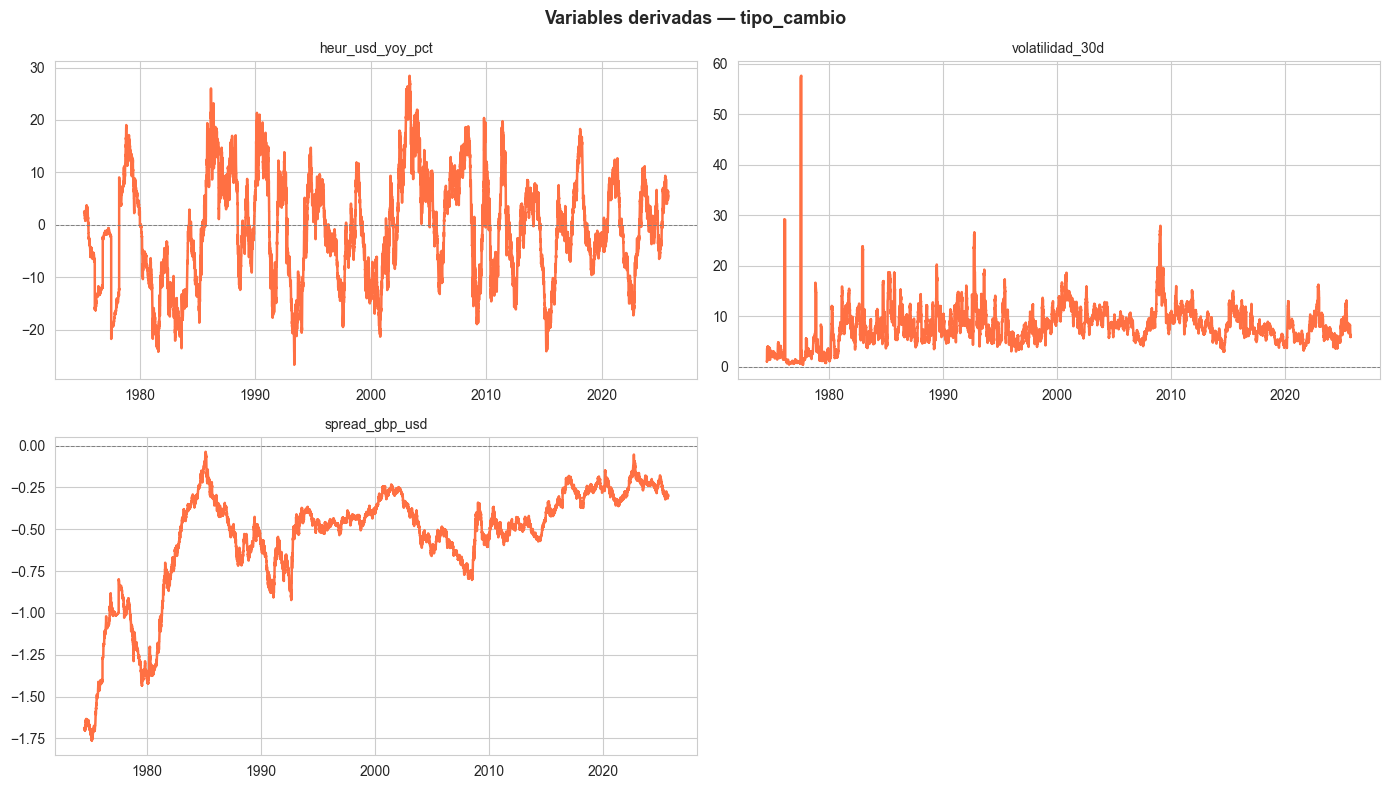

In [55]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

Las tres variables derivadas capturan dimensiones complementarias de la dinámica cambiaria, cada una con un perfil temporal y una utilidad para la modelización distintos.

`heur_usd_yoy_pct` reproduce en escala porcentual la variación interanual ya analizada en el panel de cambios periodo a periodo, con la amplitud de oscilación relativamente estable a lo largo de la muestra (rango aproximado de -26% a +28%) y media próxima a cero, confirmando el comportamiento mean-reverting del tipo de cambio. Su perfil estacionario y su interpretación directa como depreciación o apreciación del euro frente al dólar la convierten en la transformación de referencia para el cruce con la tasa de paro.

`volatilidad_30d` (desviación típica móvil de 30 días de la diferencia diaria) describe el clustering de volatilidad característico de los mercados cambiarios. El pico aislado de aproximadamente 58 en torno a 1976-1977 corresponde a los primeros años de flotación de la peseta tras el fin del sistema de Bretton Woods, cuando el mercado de divisas español tenía escasa profundidad y la volatilidad era extrema. A partir de 1985 la volatilidad se estabiliza en una banda de 5-15, con picos secundarios en 1992-1993 (crisis del SME), 2008-2009 (Lehman) y 2010-2011 (crisis de deuda soberana), todos perfectamente identificables. La reducción progresiva de la volatilidad de base desde 1985 refleja la consolidación del mercado cambiario europeo y la disciplina del SME primero y del euro después. Para la modelización, esta variable añade una dimensión de incertidumbre cambiaria que va más allá del nivel o la variación: episodios de alta volatilidad pueden deprimir la inversión y el turismo independientemente de la dirección del movimiento cambiario.

`spread_gbp_usd` (diferencia entre `HEUR_GBP` y `HEUR_USD`) describe la posición relativa de la libra frente al dólar expresada en términos del euro histórico. La serie parte de valores en torno a -1,75 en 1975 (la libra cotizaba muy por debajo del dólar en términos del euro histórico), escala hasta aproximadamente -0,15 en 1985 cuando la apreciación del USD comprime el diferencial, y oscila posteriormente en una banda de -0,75 a -0,15 con una tendencia ascendente gradual hasta valores de -0,25 a -0,20 en el tramo final. La serie no es estacionaria en nivel dado su perfil con tendencia, pero su variación puede aportar señal sobre los cambios relativos en la competitividad turística y exportadora entre los mercados anglosajones, relevante para la economía española por el peso diferencial del turismo británico y estadounidense.

In [56]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').mean()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: tipo_de_cambio_euro_historico_trimestral.csv
  Columnas: 14
  Rango: 1974-07-01 — 2025-10-01
  Observaciones: 206 trimestres


### Análisis:

La estacionalidad trimestral del `HEUR_USD` es negligible (coeficiente de variación entre trimestres del 0,58%), como confirman el boxplot trimestral, el boxplot mensual y la descomposición STL, de modo que el resampleo por media no introduce ni elimina patrón estacional alguno.

El punto relevante para la modelización es la forma de entrada de la serie. El nivel no es estacionario, por lo que el cruce cuantitativo con la tasa de paro de la sección 9 no se realiza sobre el nivel, sino sobre la primera diferencia `Δ1`, la transformación estacionaria más limpia según los tests del bloque 6.1. Cruzar en niveles produciría correlación espuria por la coincidencia de los regímenes cambiario y laboral, como ilustra el gráfico de la sección 2; el análisis cuantitativo se reserva por tanto para la forma estacionaria.

---
## 8. Tabla Resumen

In [57]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains('Δ1')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains('Δ4')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                         Valor
Dataset                                            tipo_cambio
Variable                                              HEUR_USD
Frecuencia                       trimestral (resampleo: media)
N obs original                                  15800 (diaria)
Rango                                  1974-07-01 — 2025-10-01
N obs                                                      206
Media                                                    1.400
Mediana                                                  1.270
Std                                                      0.460
CV (%)                                                  32.800
Mín (fecha)                                   0.9 (2000-10-01)
Máx (fecha)                                   3.0 (1975-04-01)
Outliers IQR                                                27
% faltantes (original)                                    0.0%
Estacionaria (niv

### Análisis:

La tabla resumen recoge los estadísticos del `HEUR_USD` sobre 15.800 observaciones diarias entre julio de 1974 y octubre de 2025 (206 trimestres tras el resampleo por media), sin valores faltantes. La media trimestral de 1,400 y la mediana de 1,270 reflejan la asimetría positiva documentada en la distribución: la cola derecha del régimen pre-1985, con valores de hasta 3,00, eleva la media por encima de la mediana. El coeficiente de variación de 32,8% es elevado pero inferior al 46,7% del `IPRI_total_industria_2025`, coherente con la naturaleza mean-reverting del tipo de cambio frente al comportamiento tendencial de los índices de precios.

Los 27 outliers por criterio IQR de la serie trimestral (1.996 sobre los datos diarios, aproximadamente el 13% de la muestra) no son anomalías estadísticas sino el segmento temporal del régimen pre-1985, con el euro histórico cotizando muy por encima de la paridad. Su número elevado confirma que ese periodo no es marginal y que el cambio de régimen estructural es una característica de la serie. El diagnóstico de no estacionariedad en niveles y de estacionariedad en primera diferencia, confirmado por los tests formales, es consistente con el patrón de raíz unitaria de los correlogramas; la diferenciación es la vía de entrada de la serie en los modelos que requieren estacionariedad, y la determinación final de su forma se difiere a la fase de feature engineering.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Tipo Cambio** y el desempleo (EPA, desde 1976Q3).

In [58]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                    # primera diferencia intertrimestral
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                            #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 HEUR_USD
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


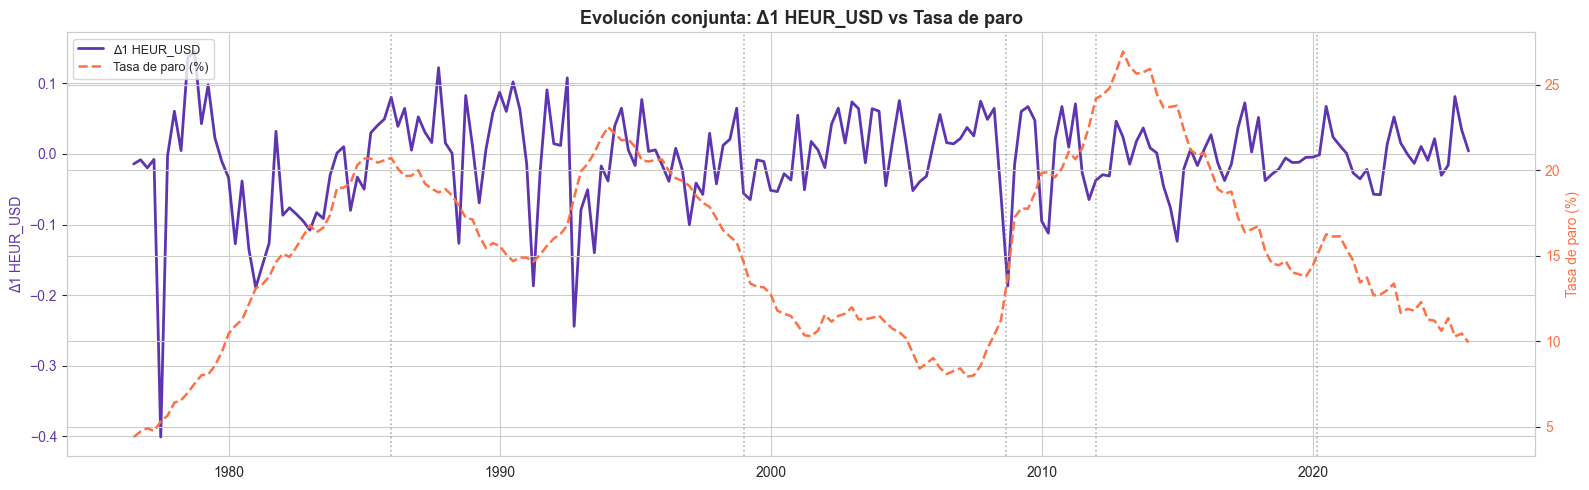

In [59]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La evolución conjunta de `Δ1` `HEUR_USD` y la tasa de paro confirma la ausencia de acoplamiento contemporáneo entre los cambios trimestrales del tipo de cambio y los ciclos del desempleo. La primera diferencia del `HEUR_USD` es una señal de media nula y amplitud aproximadamente constante a lo largo de toda la muestra (oscila en una banda de ±0,1, con picos aislados de hasta -0,4 en 1977 y -0,25 en 1992-1993), sin la heterocedasticidad progresiva que caracterizaba al IPRI ni reflejo proporcional de los grandes ciclos del paro. Los picos extremos de `Δ1` corresponden a episodios cambiarios concretos (la flotación de la peseta en la transición, las turbulencias del SME de 1992-1993), no a inflexiones del mercado laboral.

Mientras el paro recorre sus tres grandes ciclos (picos de aproximadamente 21% en 1985, 24% en 1994 y 27% en 2013, con un mínimo del 8% en 2007), la `Δ1` del tipo de cambio se comporta como ruido estacionario alrededor de cero, sin sincronización visible con esos movimientos lentos. La fuerte relación en niveles documentada en la sección anterior desaparece al diferenciar, lo que confirma que vivía en la coincidencia de regímenes de medio plazo y no en una dinámica contemporánea entre las variaciones. El análisis cuantitativo siguiente lo confirma sobre la forma estacionaria.

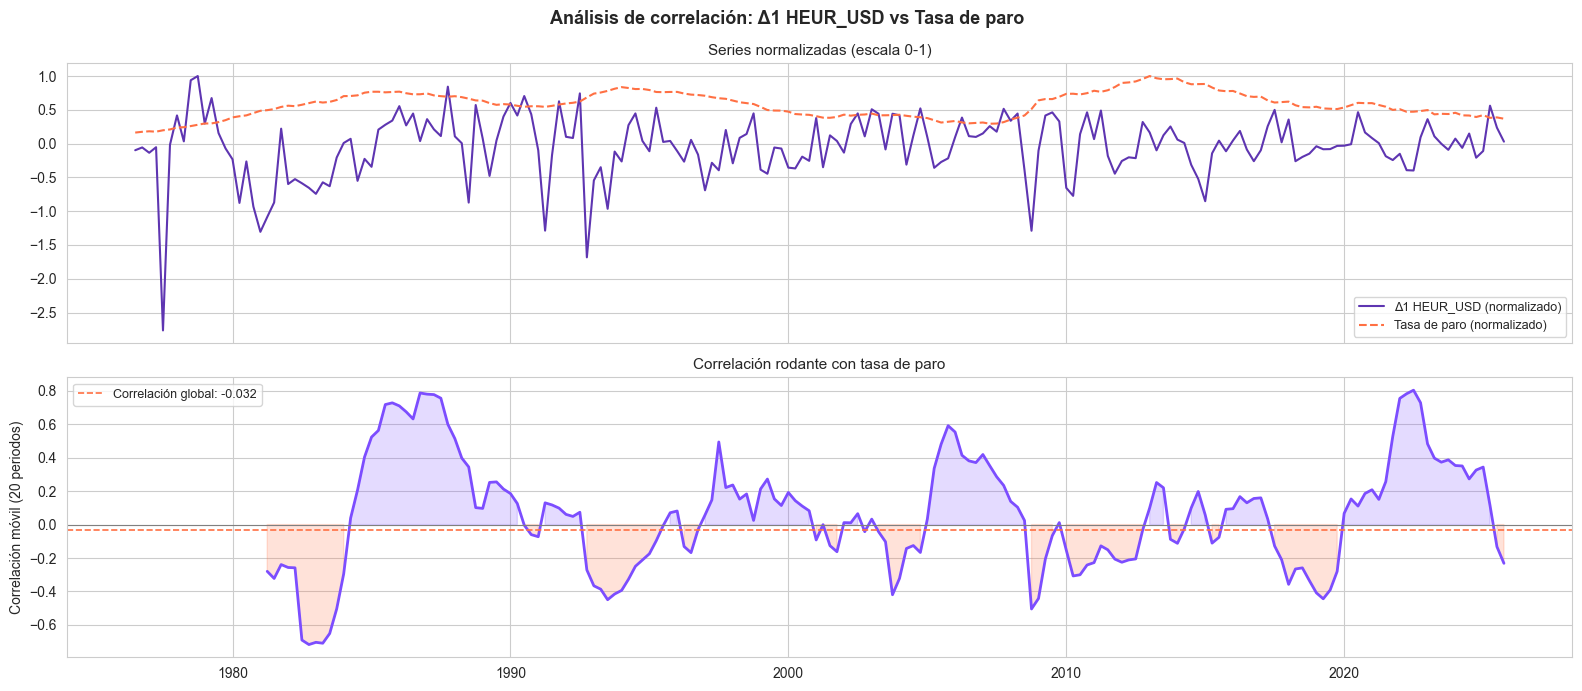

Correlación de Pearson global: -0.0321


In [60]:
ventana_corr = 20

df_cross = pd.DataFrame({'tipo_cambio': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['tipo_cambio'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['tipo_cambio'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['tipo_cambio'] / df_cross['tipo_cambio'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre `Δ1` `HEUR_USD` y la tasa de paro es de -0,0321, prácticamente nula, y contrasta de forma reveladora con el -0,3533 que arrojaba el cruce en niveles. Esa diferencia es la confirmación cuantitativa de que la correlación del nivel era espuria: la inducía la coincidencia temporal de los regímenes cambiario y laboral a lo largo de la muestra, no una relación entre las variaciones del tipo de cambio y el desempleo. Al diferenciar y eliminar esa coincidencia de regímenes, la señal contemporánea se desvanece.

La correlación rodante a 20 trimestres muestra, como en las demás variables, una inestabilidad de signo muy marcada, con oscilaciones que recorren desde aproximadamente +0,8 hasta -0,65 y numerosos cruces de cero. Se alternan regímenes de varios años: negativo en 1981-1983 (mínimo de aproximadamente -0,65), positivo en 1984-1989 (máximo de aproximadamente +0,75 en 1987), negativo en 1992-1994, positivo en 1996-1999 y 2005-2008 (aproximadamente +0,6), negativo en 2008-2010 y 2019-2020, y un fuerte repunte positivo en 2021-2023 (aproximadamente +0,8) antes de descender al final. La correlación global cercana a cero es por tanto el promedio de regímenes con signos opuestos, no evidencia de ausencia de relación.

Para la caracterización de la variable, este patrón implica que el `Δ1` `HEUR_USD` no debe descartarse pese a su correlación global nula: su relación con el paro es condicional al régimen macroeconómico, lo que se documenta aquí como hallazgo y cuyo aprovechamiento se difiere a la fase de feature engineering.

In [61]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='tipo_cambio', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'tipo_cambio': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

El diagrama de dispersión por década confirma el carácter condicionado al régimen de la relación. La nube de puntos se concentra en torno a `Δ1` ≈ 0 (los cambios trimestrales del tipo de cambio son mayoritariamente pequeños, dentro de una banda de aproximadamente ±0,1), con algún punto aislado en la cola izquierda (`Δ1` cercano a -0,4, los episodios de fuerte depreciación de los años 70). La recta de tendencia global es casi horizontal, con una pendiente ligeramente negativa coherente con la correlación global de -0,032: a lo largo de toda la muestra, la variación del tipo de cambio apenas guarda relación lineal con el nivel de paro.

La estratificación por color es la lectura más informativa: las décadas se separan en el eje vertical (nivel de paro) y no en el horizontal (`Δ1`). Los años 1970 se sitúan en la franja de paro bajo (aproximadamente 5-8%), mientras los 1980, 1990 y 2010 ocupan la franja alta (aproximadamente 15-26%), los 2000 una posición intermedia (aproximadamente 8-13%) y los 2020 el tramo de 10-16%. Que la dispersión vertical la determine la década, es decir el régimen macroeconómico, y no la magnitud del cambio cambiario, confirma que para una misma variación del tipo de cambio próxima a cero el desempleo recorre todo su rango histórico: la relación contemporánea entre ambas variables es esencialmente nula y está dominada por el régimen.

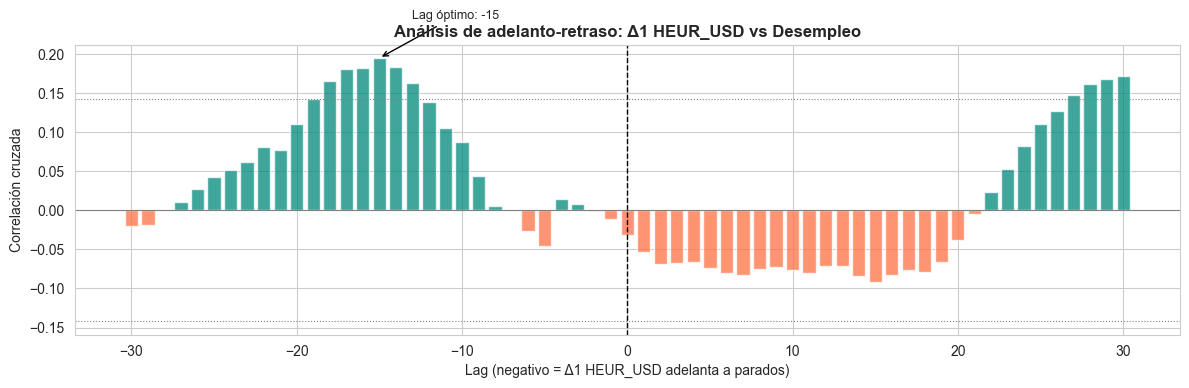

Lag con máxima correlación: -15 periodos
Correlación en ese lag: 0.1948
Banda de significancia (±2/√N): ±0.1421


In [62]:
max_lag = LAGS_ACF // 2

sa = (df_cross['tipo_cambio'] - df_cross['tipo_cambio'].mean()) / df_cross['tipo_cambio'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso muestra una estructura asimétrica pero de magnitud débil en todos los horizontes. La correlación cruzada es positiva en los lags negativos, en los que el `Δ1` `HEUR_USD` adelanta al paro, con un máximo de 0,1948 en el lag -15, y negativa en los lags positivos cortos, en los que el paro adelantaría al tipo de cambio, con valores en torno a -0,05 a -0,09. Solo el entorno del lag óptimo (lags -13 a -17) supera la banda de significancia de ±0,1421; el resto del espectro queda dentro de ella.

El lag óptimo de -15 trimestres, con correlación de 0,1948, sitúa la única señal apreciable a un horizonte de casi cuatro años: una variación cambiaria hoy se asocia a movimientos del paro con un retardo demasiado largo para ser operativo en forecasting trimestral, de modo que la lectura es descriptiva de una relación de medio-largo plazo más que de un mecanismo de transmisión aprovechable. Los lags próximos a cero, los relevantes para la predicción a corto plazo (del contemporáneo al -4), muestran correlaciones prácticamente nulas, en línea con la correlación global de -0,032, lo que confirma que la `Δ1` del tipo de cambio no aporta señal predictiva apreciable sobre el paro en horizontes de uno a cuatro trimestres por sí sola.

En conjunto, el `Δ1` `HEUR_USD` queda caracterizado como una variable de relación débil y condicionada al régimen con el desempleo; su eventual aprovechamiento, en combinación con otras variables o condicionado al régimen, se difiere a la fase de feature engineering.